In [1]:
# this code is for extracting timestamps for available lever presses from the csv files produced by the main analysis code
# timestamps will be adjusted to be relative to each period.
# e.g. an active lever press at ts = 1830 is 30 seconds into the second available period, and becomes 30 seconds.
# the purpose is to create frequency distibutions of active lever presses within avail and unavail periods.

import pandas as pd
import os

# -----------------------------
# 0. Custom column header
# -----------------------------
animal = "ACW_coh5_IT_m9"  # <-- change this each run
available_header = f"{animal}"
unavailable_header = f"{animal}"
available_adj_header = f"{animal}_adjusted"
unavailable_adj_header = f"{animal}_adjusted"

# -----------------------------
# 1. Raw timestamp input
# -----------------------------
raw_timestamps = """
6.63;7.7;8.33;128.93;319.7;381.96;1020.28;1021.78;1758.21;1758.86;1759.53;3299.83;3300.22;3347.9;3350.96;3882.75;3894.63;4221.51;4221.73;4221.96;4222.19;4223.41;4285.87;4286.54;5090.3;6708.76;7243.65;7244.96;7480.82;7546.57;7644.59;7659.69;7706.95;8629.0;10818.58;10818.64;13636.35;13830.62;13831.54;13858.73;13865.79;13868.08;14179.54;14261.72;14262.28;14269.57;14340.53;14429.18;18259.76;18279.78;18379.72;18393.76;18394.94;18396.05;19660.11;19743.09;19750.08;19795.88;19796.58;19810.58;19811.08;20085.95;20087.25
"""

timestamps = [float(t) for t in raw_timestamps.split(";") if t.strip()]

# -----------------------------
# 2. Cycle parameters
# -----------------------------
AVAILABLE_DURATION = 300      # seconds
UNAVAILABLE_DURATION = 1500  # seconds
CYCLE_LENGTH = AVAILABLE_DURATION + UNAVAILABLE_DURATION

# -----------------------------
# 3. Split timestamps and adjust
# -----------------------------
available = []
unavailable = []
available_adjusted = []
unavailable_adjusted = []

for t in timestamps:
    cycle_time = t % CYCLE_LENGTH
    if cycle_time < AVAILABLE_DURATION:
        available.append(t)
        available_adjusted.append(cycle_time)
    else:
        unavailable.append(t)
        unavailable_adjusted.append(cycle_time - AVAILABLE_DURATION)

# -----------------------------
# 4. File paths
# -----------------------------
available_file_orig = "available_timestamps_day_10.xlsx"
unavailable_file_orig = "unavailable_timestamps_day_10.xlsx"
available_file_adj = "available_timestamps_adjusted_day_10.xlsx"
unavailable_file_adj = "unavailable_timestamps_adjusted_day_10.xlsx"

# -----------------------------
# 5. Function to append columns
# -----------------------------
def append_column_to_excel(file_path, column_name, data):
    """
    Append a column to an existing Excel file, padding with NaN if needed.
    Works correctly even if the new column is longer than existing data.
    """
    # Convert new data to Series
    new_col = pd.Series(data)
    
    if os.path.exists(file_path):
        df = pd.read_excel(file_path)
        
        # Determine the maximum number of rows
        max_rows = max(len(df), len(new_col))
        
        # Reindex existing df to match max_rows (pad with NaN if needed)
        df = df.reindex(range(max_rows))
        
        # Reindex new column to match max_rows
        new_col = new_col.reindex(range(max_rows))
        
        # Add/replace the column
        df[column_name] = new_col
    else:
        # File doesn't exist, create new DataFrame
        df = pd.DataFrame({column_name: new_col})
    
    # Save back to Excel
    df.to_excel(file_path, index=False)

# -----------------------------
# 6. Append original timestamps
# -----------------------------
append_column_to_excel(available_file_orig, available_header, available)
append_column_to_excel(unavailable_file_orig, unavailable_header, unavailable)

# -----------------------------
# 7. Append adjusted timestamps
# -----------------------------
append_column_to_excel(available_file_adj, available_adj_header, available_adjusted)
append_column_to_excel(unavailable_file_adj, unavailable_adj_header, unavailable_adjusted)

# -----------------------------
# 8. Done
# -----------------------------
print("Excel files updated:")
print(f" - Original Available: {available_file_orig}")
print(f" - Original Unavailable: {unavailable_file_orig}")
print(f" - Adjusted Available: {available_file_adj}")
print(f" - Adjusted Unavailable: {unavailable_file_adj}")


# Path to the Excel file you want to check
file_path = "available_timestamps_day_10.xlsx"  # or any of your other files

# Read the Excel file into a DataFrame
df = pd.read_excel(file_path)

# View the first few rows
print(df.head())
print(df.tail())

Excel files updated:
 - Original Available: available_timestamps_day_10.xlsx
 - Original Unavailable: unavailable_timestamps_day_10.xlsx
 - Adjusted Available: available_timestamps_adjusted_day_10.xlsx
 - Adjusted Unavailable: unavailable_timestamps_adjusted_day_10.xlsx
   ACW_coh5_IT_m9
0            6.63
1            7.70
2            8.33
3          128.93
4         3882.75
    ACW_coh5_IT_m9
13        18279.78
14        19810.58
15        19811.08
16        20085.95
17        20087.25


In [2]:
#  can use the below to extract missed infusion timestamps from cohort 5 extinction and reinstatement files, since those don't log missed infusions in the same way as prior analyses



def get_infusions_from_multiline_text(multiline_text, refractory=4.0):
    rewarded_lines = []
    counts = []

    # Split into non-empty lines
    lines = [line.strip() for line in multiline_text.splitlines() if line.strip()]

    for line in lines:
        # Parse timestamps from this line
        timestamps = [
            float(t.strip())
            for t in line.split(";")
            if t.strip() != ""
        ]

        rewarded = []

        for t in timestamps:
            if not rewarded or t - rewarded[-1] >= refractory:
                rewarded.append(t)

        # Convert back to Excel-style text
        rewarded_text = ";".join(str(t) for t in rewarded)

        rewarded_lines.append(rewarded_text)
        counts.append(len(rewarded))

    return rewarded_lines, counts


multiline_text = '''1.83;2.25;43.45;97.12;132.33;160.27;185.68;186.22;202.16;249.2;250.97;251.23;283.85;688.75;700.43;704.57;705.43;804.02;805.25;807.13;869.19;870.6;878.36;879.69;1875.38
1.77;44.05;45.47;46.67;183.43;191.72;194.46;195.16;222.92;226.71;1044.3;1145.41;1546.86
1.28;1.65;15.27;64.94;65.39;71.73;73.89;74.25;74.67;75.96;358.31;358.84;363.13;367.45;2000.43;2000.91;3019.34;3020.19;3033.48
11.32;12.49;227.43;235.28;506.39;507.74;511.21;2056.81;2475.85
0.98;28.16;213.33;242.25;243.05;243.37;243.79;249.95;251.4;1009.47;1018.87;1020.37
2.66;3.3;25.59;26.32;28.94;39.8;40.74;41.41;47.21;112.16;156.09;247.51;277.12;339.64;355.38;466.61;627.23;627.63;654.57;718.82;718.99;780.49;786.14;1004.16;1011.39;1012.79;1100.85;1105.89;1109.07;1110.54;1189.85;1654.85;1805.38;1809.37;1814.46;1846.75;1851.54;2168.2;2253.33;2932.61;3034.88;3294.74
35.95;162.08;458.31;917.15;918.18;920.41;921.37;921.83;922.67;923.21;925.31;925.6;927.35;929.41;1082.77
5.91;7.4;7.48;9.38;170.4;332.27;337.19;676.59;1418.75;1419.31;1419.68;1419.85;1431.41;1431.76;2537.81
34.11;35.38;38.84;40.74;43.3;59.79;60.31;60.85;495.89;496.56;507.85;512.46;514.6;534.29;537.64;540.75;1044.52;1046.11;2510.74;2890.65;2895.31;2908.09;2912.22
1.38;94.05;95.0;95.68;121.11;124.69;127.41;239.79;241.73;244.06;443.32;444.51;461.55;462.12;484.71;485.32;894.74;923.74;925.96;952.06;1353.5;1353.7;1392.55;2182.2;2184.05'''

rewarded_lines, infusion_counts = get_infusions_from_multiline_text(multiline_text)
'''
for i, (line, count) in enumerate(zip(rewarded_lines, infusion_counts), start=1):
    print(f"Session {i}:")
    print(f"  Rewarded timestamps: {line}")
    print(f"  Total infusions: {count}\n")
   ''' 
    
import pandas as pd
pd.set_option("display.max_colwidth", None)

def get_infusions_dataframe(multiline_text, refractory=4.0):
    rows = []

    lines = [line.strip() for line in multiline_text.splitlines() if line.strip()]

    for line in lines:
        timestamps = [
            float(t.strip())
            for t in line.split(";")
            if t.strip() != ""
        ]

        rewarded = []

        for t in timestamps:
            if not rewarded or t - rewarded[-1] >= refractory:
                rewarded.append(t)

        rows.append({
            "Infusion_Count": len(rewarded),
            "Rewarded_Timestamps": ";".join(str(t) for t in rewarded)
        })

    return pd.DataFrame(rows)

df = get_infusions_dataframe(multiline_text)
df = df.reset_index(drop=True)

print(df["Infusion_Count"].to_string(index=False))
print(df["Rewarded_Timestamps"].to_string(index=False))


16
 8
11
 7
 7
32
 7
 8
15
15
                                                                                                                             1.83;43.45;97.12;132.33;160.27;185.68;202.16;249.2;283.85;688.75;700.43;704.57;804.02;869.19;878.36;1875.38
                                                                                                                                                                                  1.77;44.05;183.43;191.72;222.92;1044.3;1145.41;1546.86
                                                                                                                                                               1.28;15.27;64.94;71.73;75.96;358.31;363.13;367.45;2000.43;3019.34;3033.48
                                                                                                                                                                                       11.32;227.43;235.28;506.39;511.21;2056.81;2475.85
                                      

## file sorting


In [26]:
# file sorting

import os
import re
import shutil
from collections import defaultdict


'''
def sort_files_by_subject(folder_path):
    # Regular expression to extract the subject name
    subject_pattern = re.compile(r"(ACW_coh5_IT_[mf]\d+)")

    # Check if the folder exists
    if not os.path.isdir(folder_path):
        print(f"Error: Folder '{folder_path}' does not exist.")
        return

    # Dictionary to track files per subject
    subject_files = defaultdict(list)

    # Loop through all files in the folder
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        # Only process files (ignore folders)
        if os.path.isfile(file_path):
            match = subject_pattern.search(filename)
            if match:
                subject_name = match.group(1)
                subject_folder = os.path.join(folder_path, subject_name)

                # Create subfolder if it doesn't exist
                if not os.path.exists(subject_folder):
                    os.makedirs(subject_folder)

                # Move the file into the appropriate subfolder
                destination = os.path.join(subject_folder, filename)
                shutil.move(file_path, destination)

                # Track file under the corresponding subject
                subject_files[subject_name].append(filename)
            else:
                print(f"Skipped '{filename}' - subject name not found.")
        else:
            print(f"Skipped '{filename}' - not a file.")

    # Summary report
    print("\n📦 File summary by subject folder:")
    for subject in sorted(subject_files.keys()):
        file_list = subject_files[subject]
        print(f"\n{subject} ({len(file_list)} file{'s' if len(file_list) != 1 else ''}):")
        for fname in sorted(file_list):
            print(f"  - {fname}")
'''

import os
import re
import shutil
from collections import defaultdict

def sort_files_by_subject(folder_path, unsort=False):
    """
    Sort or unsort files by subject subfolders.
    
    Parameters:
        folder_path (str): Path to the parent folder containing files or subfolders.
        unsort (bool): If True, moves files from subfolders back to parent and deletes empty subfolders.
    """
    # Regular expression to extract the subject name
    subject_pattern = re.compile(r"(ACW_coh5_IT_[mf]\d+)")

    if not os.path.isdir(folder_path):
        print(f"Error: Folder '{folder_path}' does not exist.")
        return

    if unsort:
        # ----- UNSORT MODE -----
        subfolders = [f for f in os.listdir(folder_path) 
                      if os.path.isdir(os.path.join(folder_path, f))]
        moved_files = defaultdict(list)

        for subfolder in subfolders:
            subfolder_path = os.path.join(folder_path, subfolder)
            for fname in os.listdir(subfolder_path):
                src = os.path.join(subfolder_path, fname)
                dst = os.path.join(folder_path, fname)
                shutil.move(src, dst)
                moved_files[subfolder].append(fname)
            # Delete the empty subfolder
            os.rmdir(subfolder_path)

        # Report
        print("\n📦 Files moved back to parent folder:")
        for subj, files in moved_files.items():
            print(f"{subj} ({len(files)} file{'s' if len(files) != 1 else ''}):")
            for f in sorted(files):
                print(f"  - {f}")

    else:
        # ----- SORT MODE -----
        subject_files = defaultdict(list)
        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            if os.path.isfile(file_path):
                match = subject_pattern.search(filename)
                if match:
                    subject_name = match.group(1)
                    subject_folder = os.path.join(folder_path, subject_name)
                    if not os.path.exists(subject_folder):
                        os.makedirs(subject_folder)
                    dest = os.path.join(subject_folder, filename)
                    shutil.move(file_path, dest)
                    subject_files[subject_name].append(filename)
                else:
                    print(f"Skipped '{filename}' - subject name not found.")
            else:
                print(f"Skipped '{filename}' - not a file.")

        # Report
        print("\n📦 File summary by subject folder:")
        for subject in sorted(subject_files.keys()):
            file_list = subject_files[subject]
            print(f"\n{subject} ({len(file_list)} file{'s' if len(file_list) != 1 else ''}):")
            for fname in sorted(file_list):
                print(f"  - {fname}")

# Example usage:
# sort_files_by_subject("/path/to/your/folder")


sort_files_by_subject(r"D:\ACW\behavior\cohort_5_101325\CR", unsort=True)



📦 Files moved back to parent folder:


('D:/ACW/behavior/cohort_5_101325/IntA_SA/ACW_coh5_IT_f1/2025-10-20_11h42m_Subject ACW_coh5_IT_f1.txt', 'D:/ACW/behavior/cohort_5_101325/IntA_SA/ACW_coh5_IT_f1/2025-10-21_09h00m_Subject ACW_coh5_IT_f1.txt', 'D:/ACW/behavior/cohort_5_101325/IntA_SA/ACW_coh5_IT_f1/2025-10-22_08h48m_Subject ACW_coh5_IT_f1.txt', 'D:/ACW/behavior/cohort_5_101325/IntA_SA/ACW_coh5_IT_f1/2025-10-23_09h21m_Subject ACW_coh5_IT_f1.txt', 'D:/ACW/behavior/cohort_5_101325/IntA_SA/ACW_coh5_IT_f1/2025-10-24_08h21m_Subject ACW_coh5_IT_f1_composite.txt', 'D:/ACW/behavior/cohort_5_101325/IntA_SA/ACW_coh5_IT_f1/2025-10-25_11h16m_Subject ACW_coh5_IT_f1.txt', 'D:/ACW/behavior/cohort_5_101325/IntA_SA/ACW_coh5_IT_f1/2025-10-26_10h04m_Subject ACW_coh5_IT_f1.txt', 'D:/ACW/behavior/cohort_5_101325/IntA_SA/ACW_coh5_IT_f1/2025-10-27_10h18m_Subject ACW_coh5_IT_f1.txt', 'D:/ACW/behavior/cohort_5_101325/IntA_SA/ACW_coh5_IT_f1/2025-10-28_08h40m_Subject ACW_coh5_IT_f1.txt', 'D:/ACW/behavior/cohort_5_101325/IntA_SA/ACW_coh5_IT_f1/2025-1

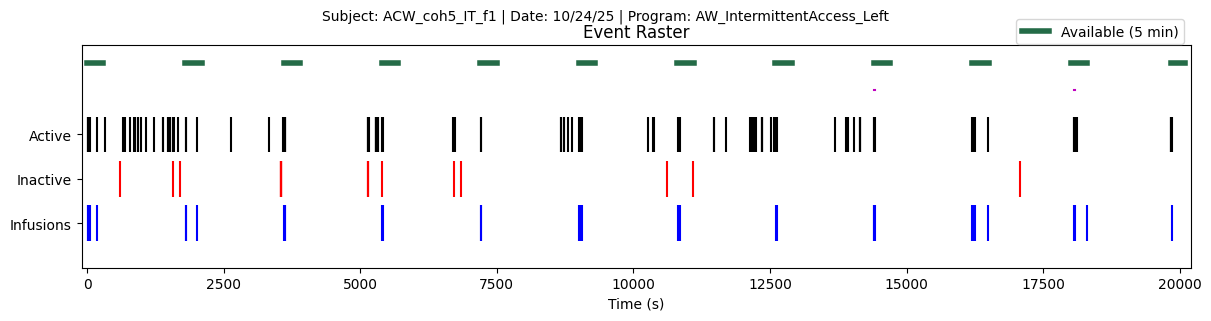

In [70]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SELF-ADMIN ANALYSIS PROGRAM
# By Aaron Garcia
# The following program was written in Python 3.12. It is intended to provide a more granular
# analysis of self-administration data. The program provies a GUI where the user can select their
# data files, where they want their results file saved, the type of event they want processed 
# (lever presses or infusions), how long they want a bin to be in seconds, the option to look for
# "burst" behavior as defined by the user, and optional drug concentration modeling for fentanyl or 
# methamphetamine. After the user has input their desired parameters, the window will withdraw and
# the data will be processed and stored in a csv file titthe user can name (default is 
# "SA_analysis_results"), which can be opened in Excel. 
# 
# The program will extract/produce: subject, date, group, session length, active lever, 
# total infusions, total presses, the event type chosen for processing, event timestamps, session
# IEI mean and SD, number of bursts, burst time, events in bursts, available/unavailable events, 
# available/unavailable IEI mean, available/unavailable IEI SD, available/unavailable R squared and 
# slope for the events across periods, available/unavailable R squared and slope for latency of first
# event across periods, available/unavailable mean latency until first event, available/unavailable 
# mean event time since period start, available/unavailable R squared and slope for mean event time
# since period start across periods, available/unavailable IEIs. It will break down each period and
# state period type, period start time in seconds, events in the period, period IEI mean, period IEI
# SD, period latency to first event, period mean event time since period start, period IEIs, period
# bursts. It then provides the number of events that occurred in each time bin specified. It then
# gives the peak drug concentration in the session, the time that peak concenctration occurred, and
# the drug concentrations per second. 
#
# The csv file will be saved in the stipulated directory. A new window will appear that shows each
# subject that was extracted in the analysis and provide the option to graph that subject's data.
# If the button is pressed, a graph will appear with the raster plot of the events, a blue line
# indicating available periods, and a purple line indicating identified bursts. Below the raster
# plot there will be a graph of the estimated drug concentration across the session. The program will
# terminate when the results window is closed.
#
# The program is intended to provide insight into the event structure of a self-administration session.
# It provides information about if the behavior is consistent/tonic or occurring in bursts and in what
# frequency. It also provides interevent interval as a way to look at the spacing of events. It looks
# at latency to first event and the average time of event since period start in order to get an idea
# of when the subject is choosing to perform events in relation to external cues like period changes.
# The average time of event since period start is intended to act like a center of gravity giving an
# idea of how the events are centered in time around the period change. Linear regressions are provided
# to give an idea of if these measures might be significantly changing across the session. The drug 
# concentration estimation is only an estimation! A one compartment model was used to estimate the 
# concentration of fentanyl, largely based on the data provided in Ohtsuka et al., 2011. The 
# methamphetamine and amphetamine estimation was done using a two compartment model that was primarily
# based on data in Milesi-Halle et al., 2015 and Milesi-Halle et al., 2005. The amphetamine estimation
# in particular should be taken as nothing more than theoretical. 
#   - AFG, 2024 

# Revisions made by Alex Whitebirch, August 2025.
# added ability to track and plot active lever, inactive lever, and infusions. 
# added code block at the end to extract data from the CSVs and organize into tables, e.g. for copy-pasting into Prism
# Oct 2025: updated to work for new versions of Med PC programs.
# This code was used to analysis Med-PC files from Cohort_5_10.13.25

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Import statements
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
from screeninfo import get_monitors
from functools import partial
from scipy import stats
import math
import os
import json
import re
import time
import statistics
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import ttk
from tkinter import filedialog as fd
from tkinter.messagebox import showinfo

# Analysis Code
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
class Model:
    def __init__(self,input_files,output_folder,filename,binsize,burst_detect_box,
                 min_events,max_iei,drug_conc_est,drug,sex,dose):
        self.input_files = input_files
        self.output_folder = output_folder
        self.filename = filename
        self.binsize = binsize
        self.burst_detect_box = burst_detect_box
        self.drug_conc_est = drug_conc_est
        self.min_events = min_events
        self.max_iei = max_iei
        self.drug = drug
        self.sex = sex
        self.dose = dose

        self.main()
    
# Analysis Methods
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    def find_session_info(self,info_line):
        try:
            delimiter = ': '
            info = info_line.strip().split(delimiter)[1]
            return info
        except:
            return None
        
    def block_extraction(self,val_list, line):
        line = line.strip()
        for val in re.split(r"\s+", line)[1:]:
            val_list.append(val)
        
    def find_active_lever(self,a_vals):
        if a_vals[0] == '0.000':
            active_lever = 'right'
        elif a_vals[0] == '1.000':
            active_lever = 'left'
        else:
            print('There is an issue with active lever designation.')
            exit()
        return active_lever
    
    def find_total_lever_presses(self,event_list,lever):
        try:
            if lever == 'right':
                lever_presses = (event_list.count('3.000') + event_list.count('8.000') + 
                event_list.count('34.000') + event_list.count('36.000'))
            elif lever == 'left':
                lever_presses = (event_list.count('4.000') + event_list.count('9.000') + 
                event_list.count('35.000') + event_list.count('37.000'))
            return lever_presses
        except:
            print('There was an issue tabulating the total lever presses.')
            
            ############   The above may be one to modify, so I can collect both active and inactive lever presses? 
    '''
    def find_total_infusions(self,event_list):
        inf = event_list.count('5.000')        # this is an issue with early cohorts that had false positive infusions, due to inappropriate timeout period from Tim's old program
        return inf
    '''
    
    def find_total_infusions(self,inf_timestamps):
        return len(inf_timestamps)
    
    def format_time(self,time_secs):
        time_formatted = time.strftime('%H:%M:%S',time.gmtime(time_secs))
        return time_formatted
    

    
    ### modified version? to create both a left and right press list
   
    
    def parse_event_list_old(self, event_list, timestamp_list):
        try:
            right_presses = ['3.000', '8.000', '34.000', '36.000']
            left_presses  = ['4.000', '9.000', '35.000', '37.000']
            drug_per_code = ['44.000', '45.000']
            inf_code = '5.000'

            event_index = 0
            left_press_timestamp_lst = []
            right_press_timestamp_lst = []
            drug_per_time_tup_list = []
            inf_timestamp_list = []

            for event in event_list:
                timestamp = timestamp_list[event_index]

                if event in right_presses:
                    right_press_timestamp_lst.append(timestamp)
                elif event in left_presses:
                    left_press_timestamp_lst.append(timestamp)
                elif event in drug_per_code:
                    drug_per_time_tup_list.append((event, timestamp))
                elif event == inf_code:
                    inf_timestamp_list.append(timestamp)

                event_index += 1

            return (left_press_timestamp_lst, right_press_timestamp_lst,
                    drug_per_time_tup_list, inf_timestamp_list)

        except Exception as e:
            print('There was an issue parsing the event list:', e)
            return None


    # will need to modify the below for cohort_5_10.13.25, since missed infusions are not logged for extinction or reinstatement programs
    # missed infusion timestamps wil instead be extracted from the active_presses timestamps, with a 4 second refractory period
        
    def parse_event_list(self, event_list, timestamp_list):
        try:
            #active_presses = ['3.000', '60.000', '62.000']
            active_presses = ['60.000', '62.000']
            #inactive_presses  = ['4.000', '61.000', '63.000']
            inactive_presses  = ['61.000', '63.000']
            drug_per_code = ['44.000', '45.000']
            inf_code = '5.000'

            event_index = 0
            active_press_timestamp_lst = []
            inactive_press_timestamp_lst = []
            drug_per_time_tup_list = []
            inf_timestamp_list = []

            '''
            # debugging with new Ped PC files, 10.01.25
            print(type(event_list[0]), event_list[:10])
            
            print(f"event_list length: {len(event_list)}, timestamp_list length: {len(timestamp_list)}")
            '''
            
            for event_index, event in enumerate(event_list):
                if event_index >= len(timestamp_list):
                    print(f"Mismatch: No timestamp for event at index {event_index}, event={event}")
                    break  # or continue to skip
                timestamp = timestamp_list[event_index]

                if event in inactive_presses:
                    inactive_press_timestamp_lst.append(timestamp)
                elif event in active_presses:
                    active_press_timestamp_lst.append(timestamp)
                elif event in drug_per_code:
                    drug_per_time_tup_list.append((event, timestamp))
                elif event == inf_code:
                    inf_timestamp_list.append(timestamp)

                event_index += 1
                
            '''
            # debugging with new Ped PC files, 10.01.25
            print("First 95 events and timestamps:")
            for i in range(min(len(event_list), len(timestamp_list))):
                print(f"{i}: event={event_list[i]}, timestamp={timestamp_list[i]}")

            if len(event_list) > len(timestamp_list):
                print(f"Extra events: {event_list[len(timestamp_list):]}")
            elif len(timestamp_list) > len(event_list):
                print(f"Extra timestamps: {timestamp_list[len(event_list):]}")
            '''
            return (active_press_timestamp_lst, inactive_press_timestamp_lst,
                    drug_per_time_tup_list, inf_timestamp_list)

        except Exception as e:
            print('There was an issue parsing the event list:', e)
            return None


            

    def find_event_interval_session(self,event_timestamp_list):
        try:
            timestamp_index = 0
            interevent_interval_list = []
            session_iei_mean = None
            session_iei_stdev = None
            if len(event_timestamp_list) > 1:
                for timestamp in event_timestamp_list:
                    if timestamp_index == 0:
                        timestamp_index += 1
                        continue
                    else:
                        interevent_interval = timestamp - (event_timestamp_list[timestamp_index - 1])
                        interevent_interval_list.append(interevent_interval)
                        timestamp_index += 1
                if len(interevent_interval_list) > 1:
                    session_iei_mean = statistics.mean(interevent_interval_list)
                    session_iei_stdev = statistics.stdev(interevent_interval_list)
            return (interevent_interval_list,session_iei_mean,session_iei_stdev)
        except:
            print('There was an issue finding the press intervals for the session.')


    # update this bin function because it was having issues with infusion bins
    
    def find_bin_events(self, event_list, bin_size, session_length):
        import math
        num_bins = math.ceil(session_length / bin_size)
        bins = [0] * num_bins

        for t in event_list:
            # Clamp t to ensure it's not placed beyond final bin
            t_clamped = min(t, session_length - 0.0001)
            bin_index = int(t_clamped // bin_size)

            # Debugging and safety (shouldn't happen with clamp, but for clarity)
            if bin_index >= num_bins:
                print(f"[WARNING] Event at {t:.2f}s exceeded session length ({session_length:.2f}s), placed in final bin.")
                bin_index = num_bins - 1

            bins[bin_index] += 1

        return bins
    
    
    def find_avail_unavail_info(self,event_timestamp_lst,drug_per_time_tup_lst):
        period_idx = 0
        periods = []
        for period in drug_per_time_tup_lst:
            tstamp_idx = 0
            start_time = float(period[1]) /100
            end_time = None
            per_type = None
            per_events = 0
            per_ieis = []
            per_iei_mean = None
            per_iei_stdev = None
            event_onset = None
            avg_event_time_since_start = None
            times_since_start = []
            if period_idx < (len(drug_per_time_tup_lst) - 1):
                end_time = float(drug_per_time_tup_lst[period_idx+1][1]) / 100
            else:
                end_time = 1 * 10**10
            if period[0] == '44.000':
                per_type = 'Available'
            elif period[0] == '45.000':
                per_type = 'Unavailable'
            else:
                per_type = 'Unknown'

            for tstamp in event_timestamp_lst:
                if (tstamp >= start_time) and (tstamp < end_time):
                    per_events += 1
                    time_since_start = tstamp - start_time
                    times_since_start.append(time_since_start)
                    if per_events == 1:
                        event_onset = tstamp - start_time
                    if per_events > 1:
                        iei = tstamp - event_timestamp_lst[tstamp_idx - 1]
                        per_ieis.append(iei)
                    tstamp_idx += 1
                else:
                    tstamp_idx += 1
                    continue
            
            if len(times_since_start) >= 1:
                avg_event_time_since_start = statistics.mean(times_since_start)
            per_ieis = [round(iei,2) for iei in per_ieis]
            if len(per_ieis) > 1:
                per_iei_mean = statistics.mean(per_ieis)
                per_iei_stdev = statistics.stdev(per_ieis)
            
            per_info = (per_type,start_time,per_events,per_ieis,per_iei_mean,per_iei_stdev,
                        event_onset,avg_event_time_since_start,times_since_start)
            periods.append(per_info)
            period_idx += 1
            
            
            
        return periods
        
        
    def cum_avail_unavail(self,periods_lst):
        avail_events = 0
        avail_ieis = []
        avail_iei_mean = None
        avail_iei_stdev = None
        unavail_events = 0
        unavail_ieis = []
        unavail_iei_mean = None
        unavail_iei_stdev = None
        unknown_events = 0
        unknown_iei_mean = None
        unknown_iei_stdev = None
        unknown_ieis = []
        avail_event_lst = []
        unavail_event_lst = []
        avail_event_onset_lst = []
        unavail_event_onset_lst = []
        avail_event_times_since_start = []
        unavail_event_times_since_start = []
        avail_pers_avg_event_times_since_start = []
        unavail_pers_avg_event_times_since_start = []
        for p in periods_lst:
            if p[0] == 'Available':
                avail_events += p[2]
                avail_ieis.extend(p[3])
                avail_event_lst.append(p[2])
                avail_event_onset_lst.append(p[6])
                avail_pers_avg_event_times_since_start.append(p[7])
                avail_event_times_since_start.extend(p[8])
            elif p[0] == 'Unavailable':
                unavail_events += p[2]
                unavail_ieis.extend(p[3])
                unavail_event_lst.append(p[2])
                unavail_event_onset_lst.append(p[6])
                unavail_pers_avg_event_times_since_start.append(p[7])
                unavail_event_times_since_start.extend(p[8])
            elif p[0] == 'Unknown':
                unknown_events += p[2]
                unknown_ieis.extend(p[3])

        if len(avail_ieis) > 1:
            avail_iei_mean = statistics.mean(avail_ieis)
            avail_iei_stdev = statistics.stdev(avail_ieis)
        if len(unavail_ieis) > 1:
            unavail_iei_mean = statistics.mean(unavail_ieis)
            unavail_iei_stdev = statistics.stdev(unavail_ieis)
        if len(unknown_ieis) > 1:
            unknown_iei_mean = statistics.mean(unknown_ieis)
            unknown_iei_stdev = statistics.stdev(unknown_ieis)

        avail_event_lst = [_ for _ in avail_event_lst if _ is not None]
        unavail_event_lst = [_ for _ in unavail_event_lst if _ is not None]
        if len(avail_event_lst) > 1:
            avail_events_x = range(0,len(avail_event_lst),1)
            lin_reg_avail_events = stats.linregress(avail_events_x,avail_event_lst)
            avail_events_r_sq = lin_reg_avail_events.rvalue
            avail_events_slope = lin_reg_avail_events.slope
        else:
            avail_events_r_sq = None
            avail_events_slope = None
        if len(unavail_event_lst) > 1:
            unavail_events_x = range(0,len(unavail_event_lst),1)
            lin_reg_unavail_events = stats.linregress(unavail_events_x,unavail_event_lst)
            unavail_events_r_sq = lin_reg_unavail_events.rvalue
            unavail_events_slope = lin_reg_unavail_events.slope
        else:
            unavail_events_r_sq = None
            unavail_events_slope = None

        avail_event_onset_lst = [_ for _ in avail_event_onset_lst if _ is not None]
        unavail_event_onset_lst = [_ for _ in unavail_event_onset_lst if _ is not None]
        if len(avail_event_onset_lst) > 1:
            avail_event_onset_x = range(0,len(avail_event_onset_lst),1)
            lin_reg_avail_event_onset = stats.linregress(avail_event_onset_x,avail_event_onset_lst)
            avail_event_onset_r_sq = lin_reg_avail_event_onset.rvalue
            avail_event_onset_slope = lin_reg_avail_event_onset.slope
        else:
            avail_event_onset_r_sq = None
            avail_event_onset_slope = None
        if len(unavail_event_onset_lst) > 1:
            unavail_event_onset_x = range(0,len(unavail_event_onset_lst),1)
            lin_reg_unavail_event_onset = stats.linregress(
                unavail_event_onset_x,unavail_event_onset_lst)
            unavail_event_onset_r_sq = lin_reg_unavail_event_onset.rvalue
            unavail_event_onset_slope = lin_reg_unavail_event_onset.slope
        else:
            unavail_event_onset_r_sq = None
            unavail_event_onset_slope = None

        avail_pers_avg_event_times_since_start = [
            _ for _ in avail_pers_avg_event_times_since_start if _ is not None
            ]
        unavail_pers_avg_event_times_since_start = [
            _ for _ in unavail_pers_avg_event_times_since_start if _ is not None
            ]
        if len(avail_pers_avg_event_times_since_start) > 1:
            avail_time_since_start_x = range(0,len(avail_pers_avg_event_times_since_start),1)
            lin_reg_avail_time_since_start = stats.linregress(avail_time_since_start_x,
                                                          avail_pers_avg_event_times_since_start)
            avail_time_since_start_r_sq = lin_reg_avail_time_since_start.rvalue
            avail_time_since_start_slope = lin_reg_avail_time_since_start.slope
        else:
            avail_time_since_start_r_sq = None
            avail_time_since_start_slope = None
        if len(unavail_pers_avg_event_times_since_start) > 1:
            unavail_time_since_start_x = range(0,len(unavail_pers_avg_event_times_since_start),1)
            lin_reg_unavail_time_since_start = stats.linregress(
                unavail_time_since_start_x,unavail_pers_avg_event_times_since_start)
            unavail_time_since_start_r_sq = lin_reg_unavail_time_since_start.rvalue
            unavail_time_since_start_slope = lin_reg_unavail_time_since_start.slope
        else:
            unavail_time_since_start_r_sq = None
            unavail_time_since_start_slope = None

        if len(avail_event_onset_lst) >= 1:
            avail_avg_event_onset = statistics.mean(avail_event_onset_lst)
        else:
            avail_avg_event_onset = None
        if len(unavail_event_onset_lst) >= 1:
            unavail_avg_event_onset = statistics.mean(unavail_event_onset_lst)
        else:
            unavail_avg_event_onset = None

        if len(avail_event_times_since_start) >= 1:
            avail_avg_event_time_since_start = statistics.mean(avail_event_times_since_start)
        else:
            avail_avg_event_time_since_start = None
        if len(unavail_event_times_since_start) >= 1:
            unavail_avg_event_time_since_start = statistics.mean(unavail_event_times_since_start)
        else:
            unavail_avg_event_time_since_start = None
        
        cum_avail_unavail_lst = [
            ('Available',avail_events,avail_ieis,avail_iei_mean,avail_iei_stdev,
             avail_events_r_sq,avail_events_slope,avail_event_onset_r_sq,avail_event_onset_slope,
             avail_avg_event_onset,avail_avg_event_time_since_start,avail_time_since_start_r_sq,
             avail_time_since_start_slope),
            ('Unavailable',unavail_events,unavail_ieis,unavail_iei_mean,unavail_iei_stdev,
             unavail_events_r_sq,unavail_events_slope,unavail_event_onset_r_sq,
             unavail_event_onset_slope,unavail_avg_event_onset,unavail_avg_event_time_since_start,
             unavail_time_since_start_r_sq,unavail_time_since_start_slope),
            ('Unknown',unknown_events,unknown_ieis,unknown_iei_mean,unknown_iei_stdev)
        ]

        return cum_avail_unavail_lst

    def burst_detection(self,interevent_interval_lst,min_num_events = 2,max_iei = 10):
        min_num_events = float(min_num_events)
        max_iei = float(max_iei)
        min_num_iei = min_num_events - 1
        iei_holding_lst = []
        
        num_bursts = 0
        total_burst_time = 0
        num_events_bursts = 0
        interevent_interval_lst_idx = 0
        
        for iei in interevent_interval_lst:
            if iei <= max_iei:
                iei_holding_lst.append(iei)
                if interevent_interval_lst_idx == (len(interevent_interval_lst) - 1) and len(
                    iei_holding_lst) >= min_num_iei:
                    num_bursts += 1
                    total_burst_time += sum(iei_holding_lst)
                    num_events_bursts += (len(iei_holding_lst) + 1)
            else:
                if len(iei_holding_lst) >= min_num_iei:
                    num_bursts += 1
                    total_burst_time += sum(iei_holding_lst)
                    num_events_bursts += (len(iei_holding_lst) + 1)
                    iei_holding_lst = []
                else:
                    iei_holding_lst = []
            interevent_interval_lst_idx += 1
               
        # added measurement of average burst duration and average number of presses per burst
        
        if num_bursts > 0:
            avg_burst_duration = total_burst_time / num_bursts
            avg_burst_events = num_events_bursts / num_bursts
        else:
            avg_burst_duration = None
            avg_burst_events = None

        return (
            num_bursts,
            total_burst_time,
            num_events_bursts,
            avg_burst_duration,
            avg_burst_events
        )
    
    def conc_modeling(self,event_timestamp_lst,sess_lng):
        fent_concentrations = []
        meth_concentrations = []
        amp_concentrations = []
        if self.drug == "Fentanyl":
            if self.sex == 'Male':
                fent_time_axis = [t for t in range(0,int(sess_lng)+1,1)]
                fent_dose = float(self.dose) * 10**6
                fent_volume = 2.98 * 1000
                fent_k_el = (.8255 / 3600)
            elif self.sex == 'Female':
                fent_time_axis = [t for t in range(0,int(sess_lng)+1,1)]
                fent_dose = float(self.dose) * 10**6
                fent_volume = 3.98 * 1000
                fent_k_el = (.75 / 3600)
            for t in fent_time_axis:
                conc = 0
                if len(event_timestamp_lst) == 0:
                    pass
                else:
                    for td in event_timestamp_lst:
                        if td <= t:
                            conc += ((fent_dose/fent_volume) * math.exp(-fent_k_el*(t - td)))
                fent_concentrations.append(conc)
            return fent_concentrations

        elif self.drug == 'Methamphetamine':
            if self.sex == 'Male':
                meth_time_axis = [t for t in range(0,int(sess_lng)+1,1)]
                meth_dose = float(self.dose)
                amp_alpha = 0.106 / 60
                amp_beta = 0.00745 / 60
                amp_a = -20
                amp_b = 20
                meth_alpha = 0.05 / 60
                meth_beta = 0.01 / 60
                meth_a = 274
                meth_b = 38
            elif self.sex == 'Female':
                meth_time_axis = [t for t in range(0,int(sess_lng)+1,1)]
                meth_dose = float(self.dose)
                amp_alpha = 0.106 / 60
                amp_beta = 0.00745 / 60
                amp_a = -20
                amp_b = 20
                meth_alpha = 0.09 / 60
                meth_beta = 0.01 / 60
                meth_a = 282
                meth_b = 102
            for t in meth_time_axis:
                meth_conc = 0
                amp_conc = 0
                if len(event_timestamp_lst) == 0:
                    pass
                else:
                    for td in event_timestamp_lst:
                        if td <= t:
                            meth_conc += (meth_dose * ((meth_a * math.exp(-meth_alpha * (t - td))) + 
                                 (meth_b * math.exp(-meth_beta * (t - td)))))
                            amp_conc += (meth_dose * ((amp_a * math.exp(-amp_alpha * (t - td))) + 
                                 (amp_b * math.exp(-amp_beta * (t - td)))))
                meth_concentrations.append(meth_conc)
                amp_concentrations.append(amp_conc)
            return (meth_concentrations,amp_concentrations)

        
        
# Analysis code main body
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~    


    def main(self):
        output_path = self.output_folder + "/" + self.filename + ".csv" 

        with open(output_path, 'w') as results_file:
            max_periods = 1
            drug_conc_length = None  # will hold lengths needed for header
            max_num_bins = 0

            for filename in self.input_files:
                with open(filename) as fn:
                    num_lines = sum(1 for _ in fn)

                with open(filename) as fhand:
                    a_block = False
                    a_vals = []
                    d_block = False
                    timestamps = []
                    e_block = False
                    events = []
                    ignore_y_block = False
                    line_count = 0

                    for line in fhand:
                        # Check for the start of the Y block and ignore following lines
                        if line.startswith('Y:'):
                            ignore_y_block = True
                            
                        # Only process blocks if not ignoring Y block
                        if not ignore_y_block:
                            while a_block:
                                self.block_extraction(a_vals, line)
                                break
                            while d_block:
                                self.block_extraction(timestamps, line)
                                break
                            while e_block:
                                self.block_extraction(events, line)
                                break

                        if line.startswith('Start Date:'):
                            date = self.find_session_info(line)
                        elif line.startswith('Subject:'):
                            subject = self.find_session_info(line)
                        elif line.startswith('MSN:'):
                            program = self.find_session_info(line)
                           # Set session_length based on program name
                            if "AW_IntermittentAccess_" in program:
                                session_length = 2010000  # 5 hours 35 minutes in hundredths of a second
                            elif "AW_Cue_Reinstatement_" in program or "AW_Extinction" in program:
                                session_length = 360000   # 1 hour in hundredths of a second
                            else:
                                session_length = None  # Will fall back to 'H:' line
                                
                        elif line.startswith('H:') and session_length is None:
                            session_length = self.find_session_info(line)
                            
                            
                        elif line.startswith('A:'):
                            a_block = True
                            
                            try:
                                next_line = next(fhand)
                                self.block_extraction(a_vals, next_line)
                            except StopIteration:
                                print(f"Error: file ended unexpectedly after 'A:' in file {filename}")
                                exit()
                                
                        elif line.startswith('B:'):
                            a_block = False
                        elif line.startswith('D:'):
                            d_block = True
                        elif line.startswith('E:'):
                            d_block = False
                            e_block = True
                        #elif (e_block and len(line.strip()) == 0) or (line_count == (num_lines - 1)):
                        elif (e_block and (len(line.strip()) == 0 or line.startswith('Y:'))):

                            # ~~~~~ Session Metadata ~~~~~
                            active_lever = self.find_active_lever(a_vals)
                            inactive_lever = 'left' if active_lever == 'right' else 'right'
                            session_length_sec = round(float(session_length) / 100)
                            session_length_formatted = self.format_time(session_length_sec)

                            # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                            # ~~~~~ Parse Events ~~~~~
                            
                            ### if analyzing MedPC files from before 10.01.25, use parse_event_list
                            
                            
                            active_presses, inactive_presses, drug_period_tstamps, infusions_tstamps = self.parse_event_list(
                                events, timestamps
                            )
                            
                    
                            ### if analyzing MedPC files from before 10.01.25, use parse_event_list_old
                        
                            '''
                         
                            left_presses, right_presses, drug_period_tstamps, infusions_tstamps = self.parse_event_list_old(
                                events, timestamps
                            )
                            
                            '''
                            # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

                            
                            # --- Convert infusion timestamps to seconds, clip if needed ---
                            raw_inf_timestamps = []
                            for t in infusions_tstamps:
                                t_sec = float(t) / 100
                                if t_sec >= session_length_sec:
                                    print(f"Warning: infusion at {t_sec:.2f}s exceeds or equals session length ({session_length_sec:.2f}s), clipping.")
                                    t_sec = session_length_sec - 0.0001
                                raw_inf_timestamps.append(t_sec)

                            # --- Sort timestamps ---
                            raw_inf_timestamps.sort()

                            # --- Apply refractory period filter (2.8s) ---
                            inf_timestamps = []
                            false_positive_count = 0
                            refractory_period = 2.8
                            refractory_end_time = -float('inf')  # initially no lockout

                            for t in raw_inf_timestamps:
                                if t >= refractory_end_time:
                                    # Valid infusion — start a new refractory period
                                    inf_timestamps.append(t)
                                    refractory_end_time = t + refractory_period
                                else:
                                    # Falls within refractory window — false positive
                                    false_positive_count += 1

                            # --- Report ---
                            if false_positive_count > 0:
                                print(f"[{subject}-{date}] — Removed {false_positive_count} false positive infusion(s) (within {refractory_period}s refractory period)")

                            # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                            # Choose active/inactive presses
                            
                               ##    this isn't necessary with the new programs (10.01.25), 
                                   ###   which have event codes for active / inactive, not left / right
                            
                            '''
                            if active_lever == 'left':
                                active_presses = left_presses
                                inactive_presses = right_presses
                            else:
                                active_presses = right_presses
                                inactive_presses = left_presses
                            '''    
                            

                            # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                            
                            
                            active_timestamps = [float(t) / 100 for t in active_presses]
                            inactive_timestamps = [float(t) / 100 for t in inactive_presses]

                            # ~~~~~ Stats for Active Lever ~~~~~
                            active_ieis = self.find_event_interval_session(active_timestamps)
                            active_periods = self.find_avail_unavail_info(active_timestamps, drug_period_tstamps)
                            active_cum = self.cum_avail_unavail(active_periods)
                            active_bins = self.find_bin_events(active_timestamps, self.binsize, session_length_sec)
                            active_burst = self.burst_detection(active_ieis[0], self.min_events, self.max_iei) if self.burst_detect_box else None

                            # ~~~~~ Stats for Inactive Lever ~~~~~
                            inactive_ieis = self.find_event_interval_session(inactive_timestamps)
                            inactive_periods = self.find_avail_unavail_info(inactive_timestamps, drug_period_tstamps)
                            inactive_cum = self.cum_avail_unavail(inactive_periods)
                            inactive_bins = self.find_bin_events(inactive_timestamps, self.binsize, session_length_sec)
                            inactive_burst = self.burst_detection(inactive_ieis[0], self.min_events, self.max_iei) if self.burst_detect_box else None

                            
                            # ~~~~~ infusion bins ~~~~~
                            
                            infusion_bins = self.find_bin_events(inf_timestamps, self.binsize, session_length_sec)
                            
                            # Track the longest bin group
                            max_num_bins = max(max_num_bins, len(active_bins), len(inactive_bins), len(infusion_bins))
                            
                            
                            # ~~~~~ Drug Concentration (if enabled) ~~~~~
                            if self.drug_conc_est == 1:
                                drug_conc = self.conc_modeling(inf_timestamps, session_length_sec)
                                # Store lengths needed for header
                                if self.drug == 'Fentanyl':
                                    drug_conc_length = len(drug_conc)
                                elif self.drug == 'Methamphetamine':
                                    drug_conc_length = (len(drug_conc[0]), len(drug_conc[1]))
                            else:
                                drug_conc_length = None

                            # ~~~~~ Update max_periods ~~~~~
                            max_periods = max(max_periods, len(active_periods), len(inactive_periods))

                            # ~~~~~ Write Row Data ~~~~~
                            total_active_presses = len(active_presses)
                            total_inactive_presses = len(inactive_presses)

                            results_file.write(('{},{},{},{},{},{},{},{},').format(
                                subject, date, program, session_length_formatted, active_lever,
                                self.find_total_infusions(inf_timestamps),   ### updated this to deal with false positive infusions
                                total_active_presses,
                                total_inactive_presses
                            ))

                            results_file.write('{}{},'.format(';'.join([str(t) for t in active_timestamps]), ''))
                            results_file.write('{}{},'.format(';'.join([str(t) for t in inactive_timestamps]), ''))
                            results_file.write('{}{},'.format(';'.join([str(t) for t in inf_timestamps]), ''))

                            results_file.write('{},{},{},{},'.format(
                                active_ieis[1], active_ieis[2], inactive_ieis[1], inactive_ieis[2]
                            ))

                            if self.burst_detect_box:
                                results_file.write('{},{},{},{},{},{},'.format(
                                    active_burst[0], active_burst[1], active_burst[2],
                                    inactive_burst[0], inactive_burst[1], inactive_burst[2]
                                ))
                                
                                results_file.write('{},{},{},{},'.format(
                                    active_burst[3], active_burst[4],  # avg duration, avg events per burst
                                    inactive_burst[3], inactive_burst[4]
                                ))
                                

                            # ~~~~~ Cum Period Stats (Active then Inactive) ~~~~~
                            def write_cum_stats(cum):
                                group_types = ['Available', 'Unavailable', 'Unknown']
                                # Build a dictionary for lookup
                                cum_dict = {group[0]: group for group in cum}

                                for g_type in group_types:
                                    group = cum_dict.get(g_type)
                                    if group:
                                        if g_type in ('Available', 'Unavailable'):
                                            stats_block = [
                                                group[1],  # Event count
                                                group[3],  # IEI mean
                                                group[4],  # IEI stdev
                                                group[5],  # Events R²
                                                group[6],  # Events slope
                                                group[7],  # Latency R²
                                                group[8],  # Latency slope
                                                group[9],  # Avg latency
                                                group[10], # Avg event time since start
                                                group[11], # Time since start R²
                                                group[12], # Time since start slope
                                                ';'.join([str(i) for i in group[2]])  # IEIs list
                                            ]
                                        else:  # Unknown
                                            stats_block = [
                                                group[1],  # Event count
                                                group[3],  # IEI mean
                                                group[4],  # IEI stdev
                                                ';'.join([str(i) for i in group[2]])  # IEIs list
                                            ] + [''] * 8  # pad to 12 fields
                                    else:
                                        stats_block = [''] * 12  # If group not found

                                    results_file.write(','.join([str(s) for s in stats_block]) + ',')


                            write_cum_stats(active_cum)
                            write_cum_stats(inactive_cum)

                            # ~~~~~ Period-Level Info ~~~~~
                            def write_periods(periods):
                                for i in range(max_periods):
                                    try:
                                        p = periods[i]
                                        dp_ieis = ';'.join([str(iei) for iei in p[3]])
                                        stats = [
                                            p[0], p[1], p[2], p[4], p[5], p[6], p[7], dp_ieis
                                        ]
                                        results_file.write(','.join([str(s) for s in stats]) + ',')
                                        if self.burst_detect_box:
                                            per_bursts = self.burst_detection(p[3], self.min_events, self.max_iei)
                                            results_file.write('{},{},{},'.format(
                                                per_bursts[0],  # burst count
                                                per_bursts[3],  # avg duration
                                                per_bursts[4]   # avg number of events
                                            ))
                                            
                                    except:
                                        results_file.write(','.join(['None'] * (11 if self.burst_detect_box else 8)) + ',')

                            write_periods(active_periods)
                            write_periods(inactive_periods)

                            # ~~~~~ Bin Data (Active lever, Inactive lever, infusions) ~~~~~
                            
                            def pad_bins(bin_list, max_len):
                                # Convert all values to strings
                                str_bins = [str(b) for b in bin_list]
                                # Pad with empty strings to max_len
                                return str_bins + [''] * (max_len - len(str_bins))
                            
                            results_file.write(','.join(pad_bins(active_bins, max_num_bins)) + ',')
                            results_file.write(','.join(pad_bins(inactive_bins, max_num_bins)) + ',')
                            results_file.write(','.join(pad_bins(infusion_bins, max_num_bins)) + ',')


                            # ~~~~~ Drug Conc Data ~~~~~
                            if self.drug_conc_est == 1:
                                if self.drug == 'Fentanyl':
                                    peak = max(drug_conc)
                                    peak_time = drug_conc.index(peak)
                                    results_file.write(f"{peak},{peak_time},")
                                    results_file.write(','.join([str(c) for c in drug_conc]) + ',')
                                elif self.drug == 'Methamphetamine':
                                    peak_meth = max(drug_conc[0])
                                    peak_meth_time = drug_conc[0].index(peak_meth)
                                    peak_amp = max(drug_conc[1])
                                    peak_amp_time = drug_conc[1].index(peak_amp)
                                    results_file.write(f"{peak_meth},{peak_meth_time},{peak_amp},{peak_amp_time},")
                                    results_file.write(','.join([str(c) for c in drug_conc[0]]) + ',')
                                    results_file.write(','.join([str(c) for c in drug_conc[1]]) + ',')

                            results_file.write('\n')

                            # Reset for next file/session
                            a_block = False
                            a_vals = []
                            d_block = False
                            timestamps = []
                            e_block = False
                            events = []

                        line_count += 1

        # ~~~~~ Write CSV Header AFTER writing all data rows ~~~~~
        self.write_csv_header(output_path, max_periods, max_num_bins, drug_conc_length)


    def write_csv_header(self, output_path, max_periods, max_num_bins, drug_conc_length):
        import os
        temp_path = self.output_folder + '/temp_file.csv'

        with open(output_path, 'r') as original_file, open(temp_path, 'w', newline='') as temp_file:
            # ~~~ Static metadata ~~~
            temp_file.write(('Subject,Date,Program,Session Length,Active Lever,Total Infusions,'
                     'Total Active Lever Presses,Total Inactive Lever Presses,'))

            # ~~~ Timestamps ~~~
            temp_file.write(('Active Lever Timestamps (s),Inactive Lever Timestamps (s),Infusion Timestamps (s),'))

            # ~~~ IEI ~~~
            temp_file.write(('Active IEI Mean (s),Active IEI SD (s),Inactive IEI Mean (s),Inactive IEI SD (s),'))

            # ~~~ Burst info ~~~
            if self.burst_detect_box:
                temp_file.write(('Active Bursts,Active Burst Time (s),Active Events in Bursts,'
                     'Inactive Bursts,Inactive Burst Time (s),Inactive Events in Bursts,'
                     'Average Active Burst Duration (s),Average Number of Active Events Per Burst,'
                     'Average Inactive Burst Duration (s),Average Number of Inactive Events Per Burst,'))

            # ~~~ Cumulative period stats ~~~
            def write_cum_labels(prefix):
                temp_file.write((
                    f'{prefix} Available Events,{prefix} Available IEI Mean (s),{prefix} Available IEI SD (s),'
                    f'{prefix} Available Events R Squared,{prefix} Available Events Slope,'
                    f'{prefix} Available Latency First Event R Squared,{prefix} Available Latency First Event Slope,'
                    f'{prefix} Available Avg Latency First Event (s),{prefix} Available Avg Event Time Since Period Start (s),'
                    f'{prefix} Available Event Time Since Period Start R Squared,'
                    f'{prefix} Available Event Time Since Period Start Slope,{prefix} Available IEIs (s),'

                    f'{prefix} Unavailable Events,{prefix} Unavailable IEI Mean (s),{prefix} Unavailable IEI SD (s),'
                    f'{prefix} Unavailable Events R Squared,{prefix} Unavailable Events Slope,'
                    f'{prefix} Unavailable Latency First Event R Squared,{prefix} Unavailable Latency First Event Slope,'
                    f'{prefix} Unavailable Avg Latency First Event (s),{prefix} Unavailable Avg Event Time Since Period Start (s),'
                    f'{prefix} Unavailable Event Time Since Period Start R Squared,'
                    f'{prefix} Unavailable Event Time Since Period Start Slope,{prefix} Unavailable IEIs (s),'

                    f'{prefix} Unknown Events,{prefix} Unknown IEI Mean (s),{prefix} Unknown IEI SD (s),'
                    f'{prefix} Unknown Events R Squared,{prefix} Unknown Events Slope,'
                    f'{prefix} Unknown Latency First Event R Squared,{prefix} Unknown Latency First Event Slope,'
                    f'{prefix} Unknown Avg Latency First Event (s),{prefix} Unknown Avg Event Time Since Period Start (s),'
                    f'{prefix} Unknown Event Time Since Period Start R Squared,'
                    f'{prefix} Unknown Event Time Since Period Start Slope,{prefix} Unknown IEIs (s),'

                ))

            write_cum_labels('Active')
            write_cum_labels('Inactive')

            # ~~~ Period-level info (Active then Inactive) ~~~
            def write_periods_labels(prefix):
                for p in range(1, max_periods + 1):
                    temp_file.write((f'{prefix} Period {p} Type,{prefix} Period {p} Start Time,'
                                     f'{prefix} Period {p} Events,{prefix} Period {p} IEI Mean (s),'
                                     f'{prefix} Period {p} IEI SD (s),{prefix} Period {p} Latency First Event (s),'
                                     f'{prefix} Period {p} Avg Event Time Since Start (s),'
                                     f'{prefix} Period {p} IEIs (s),'))
                    if self.burst_detect_box:
                        temp_file.write((
                            f'{prefix} Period {p} Bursts,'
                            f'{prefix} Period {p} Avg Burst Duration (s),'
                            f'{prefix} Period {p} Avg Events Per Burst,'
                        ))

            write_periods_labels('Active')
            write_periods_labels('Inactive')

            # ~~~ Bins (Active and Inactive) ~~~
            for b in range(1, max_num_bins + 1):
                temp_file.write(f'Active Bin {b} Events,')
            for b in range(1, max_num_bins + 1):
                temp_file.write(f'Inactive Bin {b} Events,')
            for b in range(1, max_num_bins + 1):
                temp_file.write(f'Infusion Bin {b} Events,')

            # ~~~ Drug Concentration ~~~
            if self.drug_conc_est == 1 and drug_conc_length is not None:
                if self.drug == 'Fentanyl':
                    temp_file.write('Peak Fentanyl Conc (ng/mL),Peak Fentanyl Conc Time (s),')
                    for i in range(drug_conc_length):
                        temp_file.write(f'Fentanyl Concentration {i}s,')
                elif self.drug == 'Methamphetamine':
                    peak_meth_len, peak_amp_len = drug_conc_length
                    temp_file.write('Peak Meth Conc (ng/mL),Peak Meth Conc Time (s),'
                                    'Peak Amp Conc (ng/mL),Peak Amp Conc Time (s),')
                    for i in range(peak_meth_len):
                        temp_file.write(f'Methamphetamine Concentration {i}s,')
                    for i in range(peak_amp_len):
                        temp_file.write(f'Amphetamine Concentration {i}s,')

            # ~~~ End of header line ~~~
            temp_file.write('\n')

            # Copy data rows
            for line in original_file:
                temp_file.write(line)

        # Overwrite original file with header + data
        os.replace(temp_path, output_path)


    

# GUI Code
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
class App(tk.Tk):
    def __init__(self):
        super().__init__()

        import json
        import os

        # Load previous paths if available
        try:
            with open('last_paths.json', 'r') as f:
                paths = json.load(f)
                self.last_input_dir = paths.get('input_dir', '/')
                self.last_output_dir = paths.get('output_dir', '/')
        except FileNotFoundError:
            self.last_input_dir = '/'
            self.last_output_dir = '/'
        
        # Create the root window
        self.title('Analysis Settings')
        self.resizable(False, False)

        # Place the window in the middle of the screen
        self.window_width = 650
        self.window_height = 580

        for m in get_monitors():
            if m.is_primary:
                monitor = m

        self.screen_width = monitor.width
        self.screen_height = monitor.height

        self.center_x = int((self.screen_width / 2) - (self.window_width / 2))
        self.center_y = int((self.screen_height / 2) - (self.window_height / 2))

        self.geometry('{}x{}+{}+{}'.format(self.window_width,self.window_height,self.center_x,
                                           self.center_y))
        #self.config(bg='gray94')
        self.config(bg='#96B4A0')

        # Adjust the widget style
        self.s = ttk.Style()
        self.s.configure("TMenubutton",background='white',font=('Helvetica',12))
        self.s.configure("TButton",font=('Helvetica',12))
        self.s.configure("TLabel",font=('Helvetica',12))
        self.s.configure("TCheckbutton",font=('Helvetica',12))

        # Input button
        self.input_files = None
        self.input_button = ttk.Button(
            self,
            text='Select Input Files',
            command=self.select_files,
            )

        self.input_button.grid(column=0,row=0,padx=5,pady=5)

        # Output button
        self.output_folder = None
        self.output_button = ttk.Button(
            self,
            text='Select Output Folder',
            command=self.select_output_folder
            )

        self.output_button.grid(column=1,row=0,padx=5,pady=5)

        # Filename
        self.filename_label = ttk.Label(self,text='Results Filename:')
        self.filename_label.grid(column=0,row=1,sticky=tk.E,padx=5,pady=5)

        self.filename = tk.StringVar()
        self.filename.set('ACW_coh5_IT__IntA_SA_analysis_results')                                             #~~~~~~~~~~~~~~~~~  default file name here ~~~~~~~~~~~~~~~~~~~~~~~~~#
        self.filename_entry = ttk.Entry(self,font=('Helvetica',12),textvariable=self.filename,width=18)
        self.filename_entry.grid(column=1,row=1,sticky=tk.W,padx=5,pady=5)

        # Bin size
        self.binsize_label = ttk.Label(self,text='Bin Size (s):')
        self.binsize_label.grid(column=0,row=3,sticky=tk.E,padx=5,pady=5)

        self.binsize = tk.StringVar()
        self.binsize.set(60)
        self.binsize_entry = ttk.Entry(self,font=('Helvetica',12),textvariable=self.binsize,width=10)
        self.binsize_entry.grid(column=1,row=3,sticky=tk.W,padx=5,pady=5)

        # Burst detection
        self.burst_detect = tk.IntVar()
        self.burst_detect_checkbox = ttk.Checkbutton(
            self,
            text = 'Burst Detection',
            command=self.burst_detect_clicked,
            variable=self.burst_detect
            )
        self.burst_detect_checkbox.grid(column=0,row=4,sticky=tk.W,padx=5,pady=5)

        # Minimum events in a burst
        self.min_events_burst_label = ttk.Label(self,text='Minimum events:')
        self.min_events_burst_label.grid(column=0,row=5,sticky=tk.E,padx=5,pady=5)

        self.min_events_burst = tk.StringVar()
        self.min_events_burst.set(3)
        self.min_events_burst_entry = ttk.Entry(self,font=('Helvetica',12),
                                                textvariable=self.min_events_burst,
                                                state=tk.DISABLED,width=10)
        self.min_events_burst_entry.grid(column=1,row=5,sticky=tk.W,padx=5,pady=5)

        # Maximum interevent interval
        self.max_iei_label = ttk.Label(self,text='Maximum IEI (s):')
        self.max_iei_label.grid(column=0,row=6,sticky=tk.E, padx=5,pady=5)

        self.max_iei = tk.StringVar()
        self.max_iei.set(10)
        self.max_iei_entry = ttk.Entry(self,font=('Helvetica',12),
                                       textvariable=self.max_iei,state=tk.DISABLED,width=10)
        self.max_iei_entry.grid(column=1,row=6,sticky=tk.W,padx=5,pady=5)

        # Drug concentration estimation
        self.drug_conc_est = tk.IntVar()
        self.drug_conc_checkbox = ttk.Checkbutton(
            self,
            text = 'Drug Concentration Estimation',
            command=self.drug_conc_est_clicked,
            variable=self.drug_conc_est
            )
        self.drug_conc_checkbox.grid(column=0,row=7,sticky=tk.W,padx=5,pady=5)

        # Drug choice
        self.drug_choice_label = ttk.Label(self,text='Drug:')
        self.drug_choice_label.grid(column=0,row=8,sticky=tk.E,padx=5,pady=5)

        self.drug_options = ["Fentanyl","Methamphetamine"]
        self.drug_choice = tk.StringVar()
        self.drug_option_menu = ttk.OptionMenu(
            self,
            self.drug_choice,
            self.drug_options[0],
            *self.drug_options
            )
        self.drug_option_menu.configure(state='disabled')
        self.drug_option_menu['menu'].configure(font=('Helvetica',12))
        self.drug_option_menu.grid(column=1,row=8,sticky=tk.W,padx=5,pady=5)

        # Sex choice
        self.sex_choice_label = ttk.Label(self,text='Sex:')
        self.sex_choice_label.grid(column=0,row=9,sticky=tk.E,padx=5,pady=5)

        self.sex_options = ['Male','Female']
        self.sex_choice = tk.StringVar()
        self.sex_option_menu = ttk.OptionMenu(
            self,
            self.sex_choice,
            self.sex_options[0],
            *self.sex_options
            )
        self.sex_option_menu.configure(state='disabled')
        self.sex_option_menu['menu'].configure(font=('Helvetica',12))
        self.sex_option_menu.grid(column=1,row=9,sticky=tk.W,padx=5,pady=5)

        # Dose choice
        self.dose_label = ttk.Label(self,text='Dose (mg/kg/inj):')
        self.dose_label.grid(column=0,row=10,sticky=tk.E,padx=5,pady=5)

        self.dose = tk.StringVar()
        self.dose.set(0.0015)
        self.dose_entry = ttk.Entry(self,font=('Helvetica',12),
                                    textvariable=self.dose,state=tk.DISABLED,width=10)
        self.dose_entry.grid(column=1,row=10,sticky=tk.W,padx=5,pady=5)

        # Submit button
        self.submit_button = ttk.Button(
            self,
            text='Submit',
            command=self.validate_settings
            )

        self.submit_button.grid(column=1,row=11,sticky=tk.E,padx=5,pady=5)

        # Validation check label
        self.validation_label = ttk.Label(self)
        self.validation_label.grid(column=0,row=12,sticky=tk.W,padx=5,pady=5)
    
# GUI Methods
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    def select_files(self):
        filetypes = (
            ('Text Files', '*.txt'),
            ('All Files', '*.*')
        )

        self.input_files = fd.askopenfilenames(
            title='Select Input Files',
            initialdir=self.last_input_dir,
            filetypes=filetypes
        )

        if self.input_files:
            import os, json
            self.last_input_dir = os.path.dirname(self.input_files[0])
            with open('last_paths.json', 'w') as f:
                json.dump({
                    'input_dir': self.last_input_dir,
                    'output_dir': self.last_output_dir
                }, f)

    def select_output_folder(self):
        self.output_folder = fd.askdirectory(
            title='Select Output Folder',
            initialdir=self.last_output_dir,
            mustexist=True
        )

        if self.output_folder:
            import json
            self.last_output_dir = self.output_folder
            with open('last_paths.json', 'w') as f:
                json.dump({
                    'input_dir': self.last_input_dir,
                    'output_dir': self.last_output_dir
                }, f)
    
    def burst_detect_clicked(self):
        if self.burst_detect.get() == 1:
            self.min_events_burst_entry.config(state=tk.NORMAL)
            self.max_iei_entry.config(state=tk.NORMAL)
        else:
            self.min_events_burst_entry.config(state=tk.DISABLED)
            self.max_iei_entry.config(state=tk.DISABLED)

    def drug_conc_est_clicked(self):
        if self.drug_conc_est.get() == 1:
            self.drug_option_menu.configure(state='normal')
            self.sex_option_menu.configure(state='normal')
            self.dose_entry.config(state=tk.NORMAL)
        else:
            self.drug_option_menu.configure(state='disabled')
            self.sex_option_menu.configure(state='disabled')
            self.dose_entry.config(state=tk.DISABLED)

    def plot_graph(self,sub):
        try:
            
            row_num = 0
            with open(self.output_folder + "/" + self.filename.get() + ".csv",'r') as data_file:
                for row in data_file:
                    row = row.strip()
                    if row_num == sub:
                        row = row.split(',')
                        
                        # ✅ Extract metadata from this specific row
                        subject = row[0]
                        date = row[1]
                        msn = row[2]
                        title_str = f"Subject: {subject} | Date: {date} | Program: {msn}"
                        
                        session_len_s = row[self.session_len_idx].split(':')
                        session_len_s = (float(session_len_s[0])*3600) + (
                            float(session_len_s[1])*60) + float(session_len_s[2])
                        active_events = [float(val) for val in row[self.active_idx].split(';') if val]
                        inactive_events = [float(val) for val in row[self.inactive_idx].split(';') if val]
                        infusion_events = [float(val) for val in row[self.inf_idx].split(';') if val]
                        p_idx = 0
                        p_list = row[self.per_start_idx:self.per_end_idx]
                        per_starts = []
                        per_ends = []
                        p_idx = 0
                        while p_idx < len(p_list) - 1:
                            if p_list[p_idx] == 'Available':
                                try:
                                    per_starts.append(float(p_list[p_idx + 1]))
                                except ValueError:
                                    pass  # or log warning
                            elif p_list[p_idx] == 'Unavailable':
                                try:
                                    per_ends.append(float(p_list[p_idx + 1]))
                                except ValueError:
                                    pass
                            p_idx += 2
                        if self.drug_choice.get() == 'Fentanyl':
                            fent_concentrations = [float(val) for val in row[self.fent_start_idx:-2]]
                            time_axis = [t for t in range(0,len(fent_concentrations),1)]
                            fig, axs = plt.subplots(2,1,figsize=(12,5),
                                                    gridspec_kw={'height_ratios':[1,3]},
                                                    layout='constrained')
                            
                            axs[0].eventplot([active_events, inactive_events, infusion_events],
                                             colors=['black', 'red', 'blue'],
                                             lineoffsets=[1.5, 1.0, 0.5],
                                             linelengths=0.4)
                            axs[0].set_yticks([1.5, 1.0, 0.5])
                            axs[0].set_yticklabels(['Active', 'Inactive', 'Infusions'])
                            
                            axs[0].set_title(title_str, fontsize=10, y=1.02)    
                            
                            axs[0].set_xlim(-100,len(time_axis)+100)
                            axs[0].set_ylim(0,3)
                            axs[1].plot(time_axis,fent_concentrations,color='black')
                            axs[1].set_title('Drug Concentration')
                            axs[1].set_xlabel('Time (s)')
                            axs[1].set_ylabel('Concentration (ng/mL)')
                            axs[1].set_xlim(-100,len(time_axis)+100)
                            per_starts_idx = 0
                            for s_t in per_starts:
                                if per_starts_idx == len(per_starts)-1:
                                    axs[0].plot([s_t,session_len_s],[2,2],'b')
                                else:
                                    axs[0].plot([s_t,per_ends[per_starts_idx]],[2,2],'b')
                                per_starts_idx += 1
                            current_evt_lst = []
                            try:
                                if self.burst_detect.get() == 1:
                                    def plot_bursts(events, y_offset):
                                        current_evt_lst = []
                                        for evt in events:
                                            if not current_evt_lst:
                                                current_evt_lst.append(evt)
                                            else:
                                                if (evt - current_evt_lst[-1]) < float(self.max_iei.get()):
                                                    current_evt_lst.append(evt)
                                                    if evt == events[-1] and len(current_evt_lst) >= float(self.min_events_burst.get()):
                                                        axs[0].plot([current_evt_lst[0], current_evt_lst[-1]], [y_offset, y_offset], 'm')
                                                else:
                                                    if len(current_evt_lst) >= float(self.min_events_burst.get()):
                                                        axs[0].plot([current_evt_lst[0], current_evt_lst[-1]], [y_offset, y_offset], 'm')
                                                    current_evt_lst = [evt]

                                    plot_bursts(active_events, 1.5)
                                    plot_bursts(inactive_events, 1.0)
                            except:
                                pass
                            plt.show()
                        else:
                            meth_concentrations = [float(val) for val in row[
                                self.meth_start_idx:self.meth_end_idx]]
                            amp_concentrations = [float(val) for val in row[self.amp_start_idx:-2]]
                            time_axis = [t for t in range(0,len(meth_concentrations),1)]
                            fig, axs = plt.subplots(2,1,figsize=(12,5),
                                                    gridspec_kw={'height_ratios':[1,3]},
                                                    layout='constrained')
                            
                            fig.suptitle(title_str, fontsize=10, y=1.02)
                            
                            axs[0].eventplot(raster_events,color='black')
                            axs[0].set_title('Events')
                            axs[0].set_xlim(-100,len(time_axis)+100)
                            axs[1].plot(time_axis,meth_concentrations)
                            axs[1].plot(time_axis,amp_concentrations)
                            axs[1].set_title('Drug Concentration')
                            axs[1].set_xlabel('Time (s)')
                            axs[1].set_ylabel('Concentration (ng/mL)')
                            axs[1].set_xlim(-100,len(time_axis)+100)
                            per_starts_idx = 0
                            for s_t in per_starts:
                                if per_starts_idx == len(per_starts)-1:
                                    axs[0].plot([s_t,session_len_s],[2,2],'b')
                                else:
                                    axs[0].plot([s_t,per_ends[per_starts_idx]],[2,2],'b')
                                per_starts_idx += 1
                            current_evt_lst = []
                            try:
                                if self.burst_detect.get() == 1:
                                    for evt in raster_events:
                                        if not current_evt_lst:
                                            current_evt_lst.append(evt)
                                        else:
                                            if (evt - current_evt_lst[-1]) < float(self.max_iei.get()):
                                                current_evt_lst.append(evt)
                                                if evt == raster_events[-1] and len(
                                                    current_evt_lst) >= float(
                                                    self.min_events_burst.get()):
                                                    axs[0].plot(
                                                        [current_evt_lst[0],current_evt_lst[-1]],
                                                        [1.7,1.7],'m')
                                            else:
                                                if len(current_evt_lst) >= float(
                                                    self.min_events_burst.get()):
                                                    axs[0].plot(
                                                        [current_evt_lst[0],current_evt_lst[-1]],
                                                        [1.7,1.7],'m')
                                                    current_evt_lst = [evt]
                                                else:
                                                    current_evt_lst = [evt]
                            except:
                                pass
                            plt.show()
                        break
                    row_num += 1
        
        
        except:
            row_num = 0
            with open(self.output_folder + "/" + self.filename.get() + ".csv", 'r') as data_file:
                for row in data_file:
                    row = row.strip()
                    if row_num == sub:
                        row = row.split(',')
                        
                        subject = row[0]
                        date = row[1]
                        msn = row[2]
                        title_str = f"Subject: {subject} | Date: {date} | Program: {msn}"
                        
                        session_len_s = row[self.session_len_idx].split(':')
                        session_len_s = (float(session_len_s[0]) * 3600) + (float(session_len_s[1]) * 60) + float(session_len_s[2])
                        try:
                            # Parse events
                            active_events = [float(val) for val in row[self.active_idx].split(';') if val]
                            inactive_events = [float(val) for val in row[self.inactive_idx].split(';') if val]
                            infusion_events = [float(val) for val in row[self.inf_idx].split(';') if val]

                            # Parse availability periods
                            p_idx = 0
                            p_list = row[self.per_start_idx:self.per_end_idx]
                            per_starts = []
                            per_ends = []
                            while p_idx < len(p_list) - 1:
                                if p_list[p_idx] == 'Available':
                                    try:
                                        per_starts.append(float(p_list[p_idx + 1]))
                                    except ValueError:
                                        pass
                                elif p_list[p_idx] == 'Unavailable':
                                    try:
                                        per_ends.append(float(p_list[p_idx + 1]))
                                    except ValueError:
                                        pass
                                p_idx += 2

                            time_axis = [t for t in range(0, int(session_len_s) + 1, 1)]

                            # Plot
                            fig, axs = plt.subplots(1, 1, figsize=(12, 3), layout='constrained')
                            
                            fig.suptitle(title_str, fontsize=10, y=1.02)
                            
                            axs.eventplot([active_events, inactive_events, infusion_events],
                                          colors=['black', 'red', 'blue'],
                                          lineoffsets=[1.5, 1.0, 0.5],
                                          linelengths=0.4)
                            axs.set_yticks([1.5, 1.0, 0.5])
                            axs.set_yticklabels(['Active', 'Inactive', 'Infusions'])
                            axs.set_title('Event Raster')
                            axs.set_xlim(-100, len(time_axis) + 100)
                            axs.set_ylim(0, 2.5)
                            axs.set_xlabel('Time (s)')
                            axs.plot([], [], color=[0.14, 0.42, 0.28], linewidth=4, label='Available (5 min)')
                            axs.legend(loc='upper right', bbox_to_anchor=(1, 1.15))

                            # Plot availability periods as blue horizontal lines at y=2
                            per_starts_idx = 0
                            block_length = 300  # 5 minutes in seconds
                            for s_t in per_starts:
                                line_end = s_t + block_length
                                # Don't go beyond session length
                                if line_end > session_len_s:
                                    line_end = session_len_s
                                axs.plot([s_t, line_end], [2.3, 2.3], color=[0.14, 0.42, 0.28], linewidth=4)
                                per_starts_idx += 1

                            # Burst detection plotting (optional)
                            current_evt_lst = []
                            try:
                                if self.burst_detect.get() == 1:
                                    def plot_bursts(events, y_offset):
                                        current_evt_lst = []
                                        for evt in events:
                                            if not current_evt_lst:
                                                current_evt_lst.append(evt)
                                            else:
                                                if (evt - current_evt_lst[-1]) < float(self.max_iei.get()):
                                                    current_evt_lst.append(evt)
                                                    if evt == events[-1] and len(current_evt_lst) >= float(self.min_events_burst.get()):
                                                        axs.plot([current_evt_lst[0], current_evt_lst[-1]], [y_offset, y_offset], 'm')
                                                else:
                                                    if len(current_evt_lst) >= float(self.min_events_burst.get()):
                                                        axs.plot([current_evt_lst[0], current_evt_lst[-1]], [y_offset, y_offset], 'm')
                                                    current_evt_lst = [evt]

                                    plot_bursts(active_events, 2)
                                    plot_bursts(inactive_events, 1.5)
                            except:
                                pass

                            plt.show()
                            return  # ?
                            break

                        except:
                            print('There are no events to plot.')
                            fig, ax = plt.subplots()
                            ax.set_title('No Events')
                            plt.show()
                            return    # ?
                        break
                    row_num += 1
        

    def create_results_win(self):
        # Create new new window
        results_win = tk.Toplevel(self,height=800,width=700)
        results_win.title('Results')
        results_win.resizable(True, True)

        # Place the window in the middle of the screen
        center_x = int((self.screen_width / 2) - (results_win.winfo_reqwidth() / 2))
        center_y = int((self.screen_height / 2) - (results_win.winfo_reqheight() / 2))
        results_win.geometry('{}x{}+{}+{}'.format(
            results_win.winfo_reqwidth(),results_win.winfo_reqheight(),center_x,center_y))
        results_win.config(bg='gray94')

        # Create a primary frame
        main_frame = tk.Frame(results_win)
        main_frame.pack(fill=tk.BOTH,expand=1)

        # Create a canvas
        result_canvas = tk.Canvas(main_frame)
        result_canvas.pack(side=tk.LEFT,fill=tk.BOTH,expand=1)

        # Add a y scrollbar to the canvas
        result_yscrollbar = ttk.Scrollbar(main_frame,orient=tk.VERTICAL,command=result_canvas.yview)
        result_yscrollbar.pack(side=tk.RIGHT,fill=tk.Y)

        # Add an x scrollbar to the canvas
#        result_xscrollbar = ttk.Scrollbar(main_frame,orient=tk.HORIZONTAL,command=result_canvas.xview)
#        result_xscrollbar.pack(side=tk.BOTTOM,fill=tk.X)

        # Configure the canvas
        result_canvas.configure(yscrollcommand=result_yscrollbar.set)
        result_canvas.bind('<Configure>',lambda e:result_canvas.configure(
            scrollregion=result_canvas.bbox('all')))
        
        # Create another frame inside of the canvas
        second_frame = tk.Frame(result_canvas)

        # Add the second frame to a window that will go inside the canvas
        result_canvas.create_window((0,0),window=second_frame,anchor='nw')

        # Check the data file
        with open(self.output_folder + "/" + self.filename.get() + ".csv",'r') as data_file:
            row_idx = 0
            for row in data_file:
                row = row.strip()
                if row.startswith('Subject'):
                    row = row.split(',')
                    self.session_len_idx = row.index('Session Length')
                    self.active_idx = row.index('Active Lever Timestamps (s)')
                    self.inactive_idx = row.index('Inactive Lever Timestamps (s)')
                    self.inf_idx = row.index('Infusion Timestamps (s)')
                    for item in row:
                        if "Period" in item:
                            self.per_start_idx = row.index(item)
                            break
                    for item in row:
                        if 'Bin' in item:
                            self.per_end_idx = row.index(item)-1
                            break
                    try:
                        if self.drug_choice.get() == 'Fentanyl':
                            self.fent_start_idx = row.index('Fentanyl Concentration 0s')
                        else:
                            self.meth_start_idx = row.index('Methamphetamine Concentration 0s')
                            self.amp_start_idx = row.index('Amphetamine Concentration 0s')
                            self.meth_end_idx = self.amp_start_idx - 1
                    except:
                        pass
                else:
                    row = row.split(',')
                    subj = ttk.Label(second_frame,text='Subject {} Date {}: Complete'.format(
                        row[0],row[1]))
                    subj.grid(column=0,row=row_idx,sticky=tk.W,padx=5,pady=5)

                    graph = ttk.Button(
                        second_frame,
                        text='Graph',
                        command= partial(self.plot_graph,row_idx)
                        )
                    graph.grid(column=1,row=row_idx,sticky=tk.E,padx=5,pady=5)
                row_idx += 1
        results_win.wm_protocol("WM_DELETE_WINDOW",self.destroy)

    def validate_settings(self):
        valid_filename = self.filename.get()
        valid_binsize = self.binsize.get()
        valid_min_events = self.min_events_burst.get()
        valid_max_iei = self.max_iei.get()
        valid_dose = self.dose.get()
        input_files_bool = False
        output_folder_bool = False
        filename_bool = False
        binsize_bool = False
        burst_detect_bool = False
        drug_conc_bool = False

        if self.input_files:
            input_files_bool = True
        else:
            self.validation_label.config(
                text='No input file chosen',
                foreground='red'
            )

        if self.output_folder:
            output_folder_bool = True
        else:
            self.validation_label.config(
                text='No output folder chosen',
                foreground='red'
            )

        if valid_filename:
            filename_bool = True
        else:
            self.validation_label.config(
                text='Enter a filename',
                foreground='red'
            )

        if valid_binsize:
            try:
                float(valid_binsize)
                binsize_bool = True
            except:
                self.validation_label.config(
                    text='Bin size is non-numeric',
                    foreground='red'
                )
        else:
            self.validation_label.config(
                text='Bin size entry is empty',
                foreground='red'
            )

        if self.burst_detect.get() == 1:
            if valid_min_events:
                try:
                    float(valid_min_events)
                    if valid_max_iei:
                        try:
                            float(valid_max_iei)
                            burst_detect_bool = True
                        except:
                            self.validation_label.config(
                                text='Max IEI is non-numeric',
                                foreground='red'
                            )
                    else:
                        self.validation_label.config(
                            text='Max IEI entry is empty',
                            foreground='red'
                        )
                except:
                    self.validation_label.config(
                        text='Min events is non-numeric',
                        foreground='red'
                    )
            else:
                self.validation_label.config(
                    text='Min events entry is empty',
                    foreground='red'
                )
        else:
            burst_detect_bool = True

        if self.drug_conc_est.get() == 1:
            if valid_dose:
                try:
                    float(valid_dose)
                    drug_conc_bool = True
                except:
                    self.validation_label.config(
                        text='Dose is non-numeric',
                        foreground='red'
                    )
            else:
                self.validation_label.config(
                    text='Dose entry is empty',
                    foreground='red'
                )
        else:
            drug_conc_bool = True

        validation_lst = [
            input_files_bool,
            output_folder_bool,
            binsize_bool,
            burst_detect_bool,
            drug_conc_bool,
            filename_bool
        ]

        if all(validation_lst):
            self.withdraw()
            print(
                self.input_files,
                self.output_folder,
                self.filename.get(),
                self.binsize.get(),
                self.burst_detect.get(),
                self.min_events_burst.get(),
                self.max_iei.get(),
                self.drug_conc_est.get(),
                self.drug_choice.get(),
                self.sex_choice.get(), 
            )

            Model(
                input_files=self.input_files,
                output_folder=self.output_folder,
                filename=self.filename.get(),
                binsize=float(self.binsize.get()),
                burst_detect_box=bool(self.burst_detect.get()),
                min_events=int(self.min_events_burst.get()) if self.burst_detect.get() else None,
                max_iei=float(self.max_iei.get()) if self.burst_detect.get() else None,
                drug_conc_est=bool(self.drug_conc_est.get()),
                drug=self.drug_choice.get() if self.drug_conc_est.get() else None,
                sex=self.sex_choice.get() if self.drug_conc_est.get() else None,
                dose=float(self.dose.get()) if self.drug_conc_est.get() else None
            )

            self.create_results_win()


# Improve appearance on windows
try:
    from ctypes import windll

    windll.shcore.SetProcessDpiAwareness(1)

# Run the application
finally:
    app = App()
    app.mainloop()
    
    
    

### debugging step

In [36]:
# CSV file check

import csv

def validate_csv_row_lengths(csv_path, report_path=None):
    with open(csv_path, newline='') as csvfile:
        reader = csv.reader(csvfile)
        all_rows = list(reader)

    header_len = len(all_rows[0])
    print(f"[INFO] Expected columns (from header): {header_len}")

    invalid_rows = []

    for idx, row in enumerate(all_rows[1:], start=2):  # start=2 to account for header
        if len(row) != header_len:
            print(f"[WARNING] Row {idx} has {len(row)} columns (expected {header_len})")
            invalid_rows.append((idx, row))

    if not invalid_rows:
        print("[SUCCESS] All rows have correct number of columns.")
    else:
        print(f"[ERROR] {len(invalid_rows)} row(s) have column count mismatches.")

        if report_path:
            with open(report_path, 'w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(['Row Number', 'Row Data'])
                for row_num, row_data in invalid_rows:
                    writer.writerow([row_num] + row_data)
            print(f"[INFO] Invalid rows saved to: {report_path}")
            
            
validate_csv_row_lengths(r"D:\ACW\behavior\cohort_5_101325\IntA_SA\ACW_coh5_IT_f9_IntA_SA_analysis_results.csv", "invalid_rows_report.csv")

[INFO] Expected columns (from header): 1609
[SUCCESS] All rows have correct number of columns.


# data extraction from organized CSV files


In [71]:
# data extraction from organized CSV files


import os
import pandas as pd
from glob import glob
from IPython.display import display
import numpy as np
import re


def extract_event_metrics(base_folder, bin_mode='last', final_n_days=3, specific_day = None):
    """
    Extracts session metrics and binned data from CSVs per subject folder.
    
    Parameters:
        base_folder (str): Base directory with subject subfolders.
        bin_mode (str): 'last' (default) or 'average' for how to summarize final day bin data.
        final_n_days (int): How many final days to average for bins (used if bin_mode='average')
    """
    metrics_headers = {
        'Active_Available_Events': 'Active Available Events',
        'Active_Unavailable_Events': 'Active Unavailable Events',
        'Inactive_Available_Events': 'Inactive Available Events',
        'Inactive_Unavailable_Events': 'Inactive Unavailable Events',
        'Infusions': 'Total Infusions'
    }

    bin_headers = {
        'Active_Bins': 'Active Bin',
        'Inactive_Bins': 'Inactive Bin',
        'Infusion_Bins': 'Infusion Bin'
    }
    
    burst_metrics_keys = [
    'Active_Avail_Bursts', 'Active_Avail_EventsInBurst', 'Active_Avail_BurstDuration',
    'Inactive_Avail_Bursts', 'Inactive_Avail_EventsInBurst', 'Inactive_Avail_BurstDuration',
    'Active_Unavail_Bursts', 'Active_Unavail_EventsInBurst', 'Active_Unavail_BurstDuration',
    'Inactive_Unavail_Bursts', 'Inactive_Unavail_EventsInBurst', 'Inactive_Unavail_BurstDuration'
    ]
    
    period_burst_data = {k: {} for k in burst_metrics_keys}

    latency_event_time_keys = {
            'Active_Avail_LatencyFirst': {},
            'Active_Unavail_LatencyFirst': {},
            'Active_Avail_AvgEventTime': {},
            'Active_Unavail_AvgEventTime': {},
            'Inactive_Avail_LatencyFirst': {},
            'Inactive_Unavail_LatencyFirst': {},
            'Inactive_Avail_AvgEventTime': {},
            'Inactive_Unavail_AvgEventTime': {}
        }
    
    
    # Conditionally add Session Length
    base_folder_name = os.path.basename(base_folder.rstrip(os.sep)).lower()
    if base_folder_name in ['training', 'pr']:
        print(f"Including 'Session Length' metric for: {base_folder_name}")
        metrics_headers['Session_Length'] = 'Session Length'

    metric_data = {k: {} for k in metrics_headers}
    bin_data_day1 = {k: {} for k in bin_headers}
    bin_data_final = {k: {} for k in bin_headers}
    
    cohort = os.path.basename(os.path.dirname(base_folder.rstrip(os.sep)))
    print(cohort)
    cohort_phase = f"{cohort}_{os.path.basename(base_folder.rstrip(os.sep))}"
    
    
    #~~~~~~~~~~~~~~~~~~ this block for CSV files within the base folder ~~~~~~~~~~~~~~~~~~~#
    
   
    csv_files = sorted(glob(os.path.join(base_folder, '*.csv')))
    if not csv_files:
        print("No CSV files found in base folder.")
        return

    for csv_file in csv_files:
        filename = os.path.basename(csv_file)

        # Derive subject from filename (you can customize this)
        #subject = filename.split('.')[0]  # or use regex if needed   # this works if the CSV files are located in subject folders
        # Extract subject ID as the first 4 parts of the filename
        subject_parts = filename.split('_')
        subject = '_'.join(subject_parts[:4])

        df = pd.read_csv(csv_file)

        if 'Date' not in df.columns:
            print(f"Missing 'Date' in {filename}. Skipping.")
            continue

        df['Date'] = pd.to_datetime(df['Date'])
        df.sort_values('Date', inplace=True)
        df.reset_index(drop=True, inplace=True)

       
        #~~~~~~~~~~~~~~~~~~ this block for CSV files within subject folders ~~~~~~~~~~~~~~~~~~~#
        
  
        '''
        subject_folders = sorted([
                f for f in os.listdir(base_folder)
            if os.path.isdir(os.path.join(base_folder, f)) and f.startswith("ACW_coh")    #~~~~~~~~~~~~~~~~~~~~ update this as appropriate for the specific folders ~~~~~~~~~~~~~~~~~~~~~~~~~#
        ])

        if not subject_folders:
            print("No subject folders found.")
            return

        for subject in subject_folders:
            subj_path = os.path.join(base_folder, subject)
            csv_files = glob(os.path.join(subj_path, '*.csv'))
            if not csv_files:
                print(f"No CSV file found in {subject}. Skipping.")
                continue

            df = pd.read_csv(csv_files[0])
            if 'Date' not in df.columns:
                print(f"Missing 'Date' in {csv_files[0]}. Skipping.")
                continue

            df['Date'] = pd.to_datetime(df['Date'])
            df.sort_values('Date', inplace=True)
            df.reset_index(drop=True, inplace=True)

        '''
        # ~~~~~ Compute Consistency Metric ~~~~~
        type_cols = [col for col in df.columns if col.startswith("Active Period") and "Type" in col]
        event_cols = [col for col in df.columns if col.startswith("Active Period") and "Events" in col]

        type_cols.sort()
        event_cols.sort()

        if len(type_cols) <= 1:
            print(f"[{subject}] Only one set of Active Period Type columns — skipping consistency and unavailable metrics.")
            skip_unavailable = True
        else:
            skip_unavailable = False

            consistency_values = []

            for i, row in df.iterrows():
                available_events = []

                for period_idx in range(1, 100):  # Up to 100 active periods
                    type_col = f"Active Period {period_idx} Type"
                    event_col = f"Active Period {period_idx} Events"

                    if type_col not in df.columns or event_col not in df.columns:
                        continue

                    period_type = str(row[type_col]).strip().lower()

                    if period_type == "available":
                        event_val = pd.to_numeric(row[event_col], errors='coerce')
                        if not pd.isna(event_val):
                            available_events.append(event_val)

                if not available_events:
                    consistency = float('nan')  # No available periods for this day
                else:
                    nonzero_count = sum(1 for val in available_events if val != 0)
                    consistency = (nonzero_count / len(available_events)) * 100

                consistency_values.append(consistency)

                # Store consistency values
                if 'Consistency' not in metric_data:
                    metric_data['Consistency'] = {}
                metric_data['Consistency'][subject] = consistency_values
        
        
        # ~~~~~ Parse Period-Level Burst Metrics ~~~~~
        for lever in ['Active', 'Inactive']:
            for period_idx in range(1, 100):  # assume max 100 periods
                type_col = f"{lever} Period {period_idx} Type"
                burst_col = f"{lever} Period {period_idx} Bursts"
                events_col = f"{lever} Period {period_idx} Avg Events Per Burst"
                duration_col = f"{lever} Period {period_idx} Avg Burst Duration (s)"

                if type_col not in df.columns:
                    break  # no more periods for this lever

                for day_idx, row in df.iterrows():
                    typ = str(row.get(type_col, '')).strip().lower()
                    if typ not in ['available', 'unavailable']:
                        continue

                    # Determine key prefix
                    prefix = f"{lever}_{'Avail' if typ == 'available' else 'Unavail'}"

                    # Parse bursts safely
                    raw_bursts = str(row.get(burst_col, '')).strip()
                    bursts = pd.to_numeric(raw_bursts, errors='coerce') if raw_bursts.lower() not in ['none', '', 'nan', 'invalid'] else np.nan

                    # Skip everything if bursts is NaN (bad data)
                    if pd.isna(bursts):
                        continue

                    # Parse other values
                    events = row.get(events_col, '')
                    duration = row.get(duration_col, '')

                    # Prepare per-day storage
                    for metric in ['Bursts', 'EventsInBurst', 'BurstDuration']:
                        key = f"{prefix}_{metric}"
                        period_burst_data.setdefault(key, {}).setdefault(subject, {}).setdefault(day_idx, [])

                    # Always store bursts (even if 0)
                    period_burst_data[f"{prefix}_Bursts"][subject][day_idx].append(bursts)

                    # Store the others only if bursts > 0
                    if bursts > 0:
                        # Safely convert values
                        if str(events).strip().lower() not in ['none', '', 'nan', 'invalid']:
                            events_val = pd.to_numeric(events, errors='coerce')
                            if pd.notna(events_val):
                                period_burst_data[f"{prefix}_EventsInBurst"][subject][day_idx].append(events_val)

                        if str(duration).strip().lower() not in ['none', '', 'nan', 'invalid']:
                            duration_val = pd.to_numeric(duration, errors='coerce')
                            if pd.notna(duration_val):
                                period_burst_data[f"{prefix}_BurstDuration"][subject][day_idx].append(duration_val)

        
        # ~~~~~ Parse Latency and Event Time Metrics ~~~~~

        for lever in ['Active', 'Inactive']:
            for period_idx in range(1, 100):  # up to 100 periods
                type_col = f"{lever} Period {period_idx} Type"
                latency_col = f"{lever} Period {period_idx} Latency First Event (s)"
                avg_time_col = f"{lever} Period {period_idx} Avg Event Time Since Start (s)"

                if type_col not in df.columns:
                    break

                for day_idx, row in df.iterrows():
                    typ = row.get(type_col, '').strip().lower()
                    latency = pd.to_numeric(row.get(latency_col, np.nan), errors='coerce')
                    avg_time = pd.to_numeric(row.get(avg_time_col, np.nan), errors='coerce')

                    if typ == 'available':
                        lat_key = f"{lever}_Avail_LatencyFirst"
                        time_key = f"{lever}_Avail_AvgEventTime"
                    elif typ == 'unavailable':
                        lat_key = f"{lever}_Unavail_LatencyFirst"
                        time_key = f"{lever}_Unavail_AvgEventTime"
                    else:
                        continue

                    latency_event_time_keys[lat_key].setdefault(subject, {}).setdefault(day_idx, []).append(latency)
                    latency_event_time_keys[time_key].setdefault(subject, {}).setdefault(day_idx, []).append(avg_time)
        
        
        # ~~~~~ Store Metric Data ~~~~~
        for key, col in metrics_headers.items():
            # Skip unavailable event metrics if flagged
            if skip_unavailable and 'Unavailable' in key:
                continue
            if col in df.columns:
                if key == 'Session_Length':
                    def convert_to_minutes(time_str):
                        try:
                            h, m, s = map(int, str(time_str).split(':'))
                            total_minutes = h * 60 + m + s / 60
                            total_minutes = round(total_minutes, 2)
                            total_minutes = total_minutes + 0.33
                            return total_minutes
                        except Exception as e:
                            print(f"Warning: could not parse time '{time_str}' for {subject}: {e}")
                            return np.nan

                    metric_data[key][subject] = df[col].apply(convert_to_minutes).tolist()
                else:
                    metric_data[key][subject] = df[col].tolist()

            else:
                print(f"Missing column '{col}' in {subject}. Skipping.")

                
        # ~~~~~ Store Bin Data (Day 1 and Final/Average) ~~~~~
        for bin_key, prefix in bin_headers.items():
            bin_cols = [col for col in df.columns if col.startswith(prefix)]
            if not bin_cols:
                print(f"No columns starting with '{prefix}' in {subject}. Skipping bins.")
                continue

            bins_matrix = df[bin_cols].values  # shape: (days, bins)

            # First day
            bin_data_day1[bin_key][subject] = bins_matrix[0]

            # Final bins depending on mode
            if bin_mode == 'average':
                selected = bins_matrix[-final_n_days:]
                avg = selected.mean(axis=0)
                bin_data_final[bin_key][subject] = avg

            elif bin_mode == 'last':
                bin_data_final[bin_key][subject] = bins_matrix[-1]

            elif bin_mode == 'day':
                if specific_day is None:
                    print(f"'day' bin_mode requires specific_day. Skipping {subject}.")
                    continue
                if specific_day <= 0 or specific_day > bins_matrix.shape[0]:
                    print(f"[{subject}] Invalid specific_day={specific_day}. Must be within session count ({bins_matrix.shape[0]}). Skipping.")
                    continue
                bin_data_final[bin_key][subject] = bins_matrix[specific_day - 1]  # 0-indexed

            else:
                print(f"Unknown bin_mode: {bin_mode}. Skipping {subject}.")
                
        
        

    output_dfs = {}

    # Save metric DataFrames
    for key, subj_data in metric_data.items():
        
        # Skip entirely if no subjects have data
        if not subj_data:
            print(f"Skipping save for '{key}' — no data collected.")
            continue
            
        # Debug: check lengths before creating DataFrame
        lengths = {subj: len(vals) for subj, vals in subj_data.items()}
        print(f"Lengths for key '{key}': {lengths}")

        '''
        # Check if all lengths are equal
        unique_lengths = set(lengths.values())
        if len(unique_lengths) > 1:
            print(f"⚠️ Inconsistent lengths found for '{key}': {lengths}")
            continue  # Skip this metric or handle appropriately 
        '''
            
        # --- NEW: pad shorter lists with NaN ---
        max_len = max(lengths.values())
        padded = {}
        for subj, vals in subj_data.items():
            padded_vals = list(vals) + [np.nan] * (max_len - len(vals))
            padded[subj] = padded_vals

        subj_data = padded

        
        #lengths = {subj: len(vals) for subj, vals in subj_data.items()}
        #print(f"{key} lengths per subject:", lengths)
        if not subj_data:
            print(f"Skipping save for '{key}' — no data collected.")
            continue
            
        df_out = pd.DataFrame.from_dict(subj_data, orient='columns')
        df_out.index = df_out.index + 1  # Day 1, 2, ...
        df_out.index.name = 'Day'
        #df_out = df_out[::-1]  # reverse so day 1 is at the top
        output_dfs[key] = df_out

        csv_path = os.path.join(base_folder, f"{cohort_phase}_{key}.csv")
        feather_path = os.path.join(base_folder, f"{cohort_phase}_{key}.feather")

        if not os.path.exists(csv_path):
            df_out.to_csv(csv_path)
            print(f"Saved {csv_path}")
        else:
            print(f"Skipped saving — file already exists: {csv_path}")

        if not os.path.exists(feather_path):
            df_out.reset_index().to_feather(feather_path)
            print(f"Saved {feather_path}")
        else:
            print(f"Skipped saving — file already exists: {feather_path}")

    # Helper: Save bin DataFrames
    def save_bin_set(bin_dict, suffix):
        for key, subj_data in bin_dict.items():
            # Skip if no data
            if not subj_data:
                print(f"No data found for {key}_{suffix}. Skipping.")
                continue

            # Get max length of any bin array
            max_len = max(len(arr) for arr in subj_data.values())

            # Pad all arrays to match max_len using NaN
            padded_data = {}
            for subj, arr in subj_data.items():
                arr = pd.Series(arr, dtype='float64')  # ensure numeric
                if len(arr) < max_len:
                    arr = arr.reindex(range(max_len), fill_value=np.nan)
                padded_data[subj] = arr.values  # keep as array

            # Build DataFrame safely
            df_out = pd.DataFrame.from_dict(padded_data, orient='columns')
            df_out.index = [f"Bin {i+1}" for i in range(max_len)]
            df_out.index.name = 'Bin'
            output_dfs[f"{key}_{suffix}"] = df_out

            csv_path = os.path.join(base_folder, f"{cohort_phase}_{key}_{suffix}.csv")
            feather_path = os.path.join(base_folder, f"{cohort_phase}_{key}_{suffix}.feather")

            if not os.path.exists(csv_path):
                df_out.to_csv(csv_path)
                print(f"Saved {csv_path}")
            else:
                print(f"Skipped saving — file already exists: {csv_path}")

            if not os.path.exists(feather_path):
                df_out.reset_index().to_feather(feather_path)
                print(f"Saved {feather_path}")
            else:
                print(f"Skipped saving — file already exists: {feather_path}")

            
            
    # Choose suffix based on bin_mode
    if bin_mode == 'average':
        suffix = f"avg_last_{final_n_days}_days"
    elif bin_mode == 'day':
        suffix = f"day_{specific_day}"
    elif bin_mode == 'last':
        suffix = "last_day"
    else:
        suffix = "unknown_mode"

    save_bin_set(bin_data_day1, 'day1')
    save_bin_set(bin_data_final, suffix)

    
    
    # Aggregate burst metrics across periods for each session (day)
    for key, subj_day_dict in period_burst_data.items():
        final_df = pd.DataFrame()

        for subj, day_dict in subj_day_dict.items():
            series_list = []
            for day in sorted(day_dict.keys()):
                raw_vals = day_dict[day]

                # Filter out invalid values before numeric conversion
                cleaned = [v for v in raw_vals if str(v).strip().lower() not in ['None', 'none', 'nan', '', 'invalid']]
                vals = pd.to_numeric(pd.Series(cleaned, dtype='float64'), errors='coerce')

                # Decide aggregation: sum for burst count, mean for the others
                if key.endswith('_Bursts'):
                    agg_val = vals.sum(skipna=True)
                else:
                    agg_val = vals.mean(skipna=True)

                series_list.append(agg_val)

            final_df[subj] = pd.Series(series_list)

        final_df.index = final_df.index + 1
        final_df.index.name = 'Day'
        output_dfs[key] = final_df

        # Save
        csv_path = os.path.join(base_folder, f"{cohort_phase}_{key}.csv")
        feather_path = os.path.join(base_folder, f"{cohort_phase}_{key}.feather")

        if not os.path.exists(csv_path):
            final_df.to_csv(csv_path)
            print(f"Saved {csv_path}")
        else:
            print(f"Skipped saving — file already exists: {csv_path}")

        if not os.path.exists(feather_path):
            final_df.reset_index().to_feather(feather_path)
            print(f"Saved {feather_path}")
        else:
            print(f"Skipped saving — file already exists: {feather_path}")

    
    # Aggregate latency and avg event time metrics across periods
    for key, subj_day_dict in latency_event_time_keys.items():
        final_df = pd.DataFrame()

        for subj, day_dict in subj_day_dict.items():
            series_list = []
            for day in sorted(day_dict.keys()):
                vals = pd.Series(day_dict[day])
                mean_val = vals.mean(skipna=True)
                series_list.append(mean_val)
            final_df[subj] = pd.Series(series_list)

        final_df.index = final_df.index + 1
        final_df.index.name = 'Day'
        output_dfs[key] = final_df

        # Save
        csv_path = os.path.join(base_folder, f"{cohort_phase}_{key}.csv")
        feather_path = os.path.join(base_folder, f"{cohort_phase}_{key}.feather")

        if not os.path.exists(csv_path):
            final_df.to_csv(csv_path)
            print(f"Saved {csv_path}")
        else:
            print(f"Skipped saving — file already exists: {csv_path}")

        if not os.path.exists(feather_path):
            final_df.reset_index().to_feather(feather_path)
            print(f"Saved {feather_path}")
        else:
            print(f"Skipped saving — file already exists: {feather_path}")
    
    
    return output_dfs


#################################################################################
    
    
dfs = extract_event_metrics(
    base_folder=r"D:\ACW\behavior\cohort_5_101325\IntA_SA",
    bin_mode='average',   # 'average', 'day', or  'last' depending on the objective for the endpoint bin data. First day is collected regardless. 
    final_n_days=3,       # used only if bin_mode is 'average'
    specific_day=6        # used only if bin mode is 'day'
)



#################################################################################

print('\n~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~\n')

for key in [
    'Active_Available_Events',
    'Active_Unavailable_Events',
    'Inactive_Available_Events',
    'Inactive_Unavailable_Events',
    'Infusions',
    'Consistency'
]:
    if key in dfs:
        print(f"\n{key.replace('_', ' ')}\n")
        display(dfs[key])

if 'consistency' in dfs:
    consistency_df = dfs['consistency']
    print("consistency overall:")
    print(consistency_df.mean())
    print("consistency day 1:")
    print(consistency_df.iloc[0])
    print("\nconsistency of last 3 rows:")
    print(consistency_df.tail(3).mean())


for key in [
    'Active_Avail_LatencyFirst',
    'Active_Unavail_LatencyFirst',
    'Active_Avail_AvgEventTime',
    'Active_Unavail_AvgEventTime',
    'Inactive_Avail_LatencyFirst',
    'Inactive_Unavail_LatencyFirst',
    'Inactive_Avail_AvgEventTime',
    'Inactive_Unavail_AvgEventTime'
]:
    if key in dfs:
        print(f"\n{key.replace('_', ' ')}\n")
        display(dfs[key])
        

for key, df in dfs.items():
    if 'Bin' in key:  # or more specific: if 'Bins' in key or 'bin' in key.lower()
        print(f"\n--- {key} ---")
        display(df)
        
for key in [
    'Active_Avail_Bursts', 'Active_Avail_EventsInBurst', 'Active_Avail_BurstDuration',
    'Inactive_Avail_Bursts', 'Inactive_Avail_EventsInBurst', 'Inactive_Avail_BurstDuration',
    'Active_Unavail_Bursts', 'Active_Unavail_EventsInBurst', 'Active_Unavail_BurstDuration',
    'Inactive_Unavail_Bursts', 'Inactive_Unavail_EventsInBurst', 'Inactive_Unavail_BurstDuration'
    ]:
    if key in dfs:
        print(f"\n{key.replace('_', ' ')}\n")
        display(dfs[key])

#################################################################################

cohort_5_101325
Missing 'Date' in cohort_5_101325_IntA_SA_Active_Avail_AvgEventTime.csv. Skipping.
Missing 'Date' in cohort_5_101325_IntA_SA_Active_Avail_LatencyFirst.csv. Skipping.
Missing 'Date' in cohort_5_101325_IntA_SA_Active_Available_Events.csv. Skipping.
Missing 'Date' in cohort_5_101325_IntA_SA_Active_Bins_avg_last_3_days.csv. Skipping.
Missing 'Date' in cohort_5_101325_IntA_SA_Active_Bins_day1.csv. Skipping.
Missing 'Date' in cohort_5_101325_IntA_SA_Active_Unavail_AvgEventTime.csv. Skipping.
Missing 'Date' in cohort_5_101325_IntA_SA_Active_Unavail_LatencyFirst.csv. Skipping.
Missing 'Date' in cohort_5_101325_IntA_SA_Active_Unavailable_Events.csv. Skipping.
Missing 'Date' in cohort_5_101325_IntA_SA_Consistency.csv. Skipping.
Missing 'Date' in cohort_5_101325_IntA_SA_Inactive_Avail_AvgEventTime.csv. Skipping.
Missing 'Date' in cohort_5_101325_IntA_SA_Inactive_Avail_LatencyFirst.csv. Skipping.
Missing 'Date' in cohort_5_101325_IntA_SA_Inactive_Available_Events.csv. Skipping.
Mis

,ACW_coh5_IT_f10,ACW_coh5_IT_f12,ACW_coh5_IT_f13,ACW_coh5_IT_f1,ACW_coh5_IT_f2,ACW_coh5_IT_f3,ACW_coh5_IT_f4,ACW_coh5_IT_f5,ACW_coh5_IT_f6,ACW_coh5_IT_f9,ACW_coh5_IT_m10,ACW_coh5_IT_m3,ACW_coh5_IT_m4,ACW_coh5_IT_m5,ACW_coh5_IT_m8,ACW_coh5_IT_m9
Day,,,,,,,,,,,,,,,,
1,43,10,51,65,29,15,10,39,48,49,11,29,21,13,26,10
2,27,60,66,48,39,11,12,53,55,35,7,36,6,24,29,12
3,40,77,57,40,48,6,23,33,34,33,5,37,9,29,31,6
4,17,51,36,28,44,7,15,41,33,18,6,50,18,13,37,6
5,15,76,44,37,37,8,28,52,42,32,7,42,34,15,38,7
6,29,77,91,57,46,12,38,62,43,62,5,45,58,10,61,8
7,3,104,49,35,67,3,19,56,52,48,3,62,36,2,54,4
8,21,58,61,44,45,4,38,38,60,51,4,48,39,8,62,7
9,31,125,43,60,70,5,32,57,37,38,3,40,42,7,61,11



Active Unavailable Events



,ACW_coh5_IT_f10,ACW_coh5_IT_f12,ACW_coh5_IT_f13,ACW_coh5_IT_f1,ACW_coh5_IT_f2,ACW_coh5_IT_f3,ACW_coh5_IT_f4,ACW_coh5_IT_f5,ACW_coh5_IT_f6,ACW_coh5_IT_f9,ACW_coh5_IT_m10,ACW_coh5_IT_m3,ACW_coh5_IT_m4,ACW_coh5_IT_m5,ACW_coh5_IT_m8,ACW_coh5_IT_m9
Day,,,,,,,,,,,,,,,,
1,94,22,101,64,83,28,50,214,221,135,43,92,43,94,79,31
2,49,152,55,85,23,8,32,71,77,25,10,60,44,26,33,19
3,42,72,33,55,22,2,35,44,76,11,7,57,31,111,60,25
4,9,36,29,35,26,11,37,32,39,43,15,33,17,12,32,12
5,21,40,18,71,32,6,51,42,44,40,5,41,60,16,30,5
6,30,69,102,20,35,12,70,13,47,6,4,41,124,18,20,39
7,2,24,41,29,21,10,38,6,9,23,11,24,33,11,57,10
8,15,31,22,26,28,1,30,34,1,29,4,31,29,5,19,7
9,22,45,32,22,25,0,20,13,4,21,8,20,100,4,27,16



Inactive Available Events



...

,ACW_coh5_IT_f10,ACW_coh5_IT_f12,ACW_coh5_IT_f13,ACW_coh5_IT_f1,ACW_coh5_IT_f2,ACW_coh5_IT_f3,ACW_coh5_IT_f4,ACW_coh5_IT_f5,ACW_coh5_IT_f6,ACW_coh5_IT_f9,ACW_coh5_IT_m10,ACW_coh5_IT_m3,ACW_coh5_IT_m4,ACW_coh5_IT_m5,ACW_coh5_IT_m8,ACW_coh5_IT_m9
Day,,,,,,,,,,,,,,,,
1,2.0,1.0,4.0,0.0,3.0,0.0,1.0,15.0,3.0,6.0,0.0,4.0,2.0,1.0,0.0,0.0
2,5.0,1.0,0.0,1.0,0.0,2.0,2.0,5.0,2.0,0.0,1.0,1.0,1.0,0.0,3.0,2.0
3,7.0,1.0,1.0,5.0,1.0,2.0,0.0,1.0,3.0,0.0,1.0,2.0,1.0,5.0,0.0,1.0
4,2.0,1.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,3.0,0.0,0.0,2.0,0.0,3.0,2.0
5,2.0,1.0,1.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
6,2.0,0.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0
7,0.0,1.0,2.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
8,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
9,0.0,3.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0



Inactive Unavail EventsInBurst



,ACW_coh5_IT_f10,ACW_coh5_IT_f12,ACW_coh5_IT_f13,ACW_coh5_IT_f1,ACW_coh5_IT_f2,ACW_coh5_IT_f3,ACW_coh5_IT_f4,ACW_coh5_IT_f5,ACW_coh5_IT_f6,ACW_coh5_IT_f9,ACW_coh5_IT_m10,ACW_coh5_IT_m3,ACW_coh5_IT_m4,ACW_coh5_IT_m5,ACW_coh5_IT_m8,ACW_coh5_IT_m9
Day,,,,,,,,,,,,,,,,
1,4.500,3.0,3.25,NaN,3.0,NaN,9.00,3.571429,4.000000,5.833333,NaN,5.0,4.5,3.00,NaN,NaN
2,4.375,3.0,NaN,3.0,NaN,4.0,3.00,4.875000,7.500000,NaN,4.0,3.0,3.0,NaN,4.666667,6.0
3,5.600,4.0,3.00,4.4,3.0,4.0,NaN,3.000000,3.666667,NaN,4.0,4.5,3.0,6.75,NaN,5.0
4,3.000,4.0,NaN,3.0,NaN,NaN,6.00,NaN,3.000000,4.333333,NaN,NaN,3.5,NaN,3.333333,4.0
5,3.500,3.0,3.00,4.0,NaN,NaN,6.00,NaN,NaN,NaN,NaN,NaN,NaN,3.00,3.000000,NaN
6,3.000,NaN,3.00,NaN,NaN,NaN,3.00,3.000000,NaN,NaN,NaN,NaN,3.0,7.00,NaN,NaN
7,NaN,14.0,3.00,NaN,3.0,3.0,3.00,NaN,NaN,NaN,NaN,3.0,NaN,NaN,3.000000,NaN
8,3.000,4.0,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.5
9,NaN,3.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.00,3.000000,3.0



Inactive Unavail BurstDuration



,ACW_coh5_IT_f10,ACW_coh5_IT_f12,ACW_coh5_IT_f13,ACW_coh5_IT_f1,ACW_coh5_IT_f2,ACW_coh5_IT_f3,ACW_coh5_IT_f4,ACW_coh5_IT_f5,ACW_coh5_IT_f6,ACW_coh5_IT_f9,ACW_coh5_IT_m10,ACW_coh5_IT_m3,ACW_coh5_IT_m4,ACW_coh5_IT_m5,ACW_coh5_IT_m8,ACW_coh5_IT_m9
Day,,,,,,,,,,,,,,,,
1,4.32500,4.4100,2.600,NaN,2.5075,NaN,19.930,5.640952,3.200000,7.281667,NaN,13.4350,10.40,5.8500,NaN,NaN
2,5.31875,5.5600,NaN,0.540,NaN,8.40,3.005,11.253750,11.985000,NaN,2.15,9.3700,1.14,NaN,13.180000,9.470
3,6.69600,6.2300,2.640,4.510,5.4000,9.72,NaN,15.540000,4.513333,NaN,3.14,6.5700,14.73,8.3775,NaN,4.120
4,6.49500,2.7200,NaN,2.530,NaN,NaN,7.770,NaN,3.240000,6.610000,NaN,NaN,8.44,NaN,5.846667,11.450
5,9.56000,1.1700,5.240,1.935,NaN,NaN,6.350,NaN,NaN,NaN,NaN,NaN,NaN,10.1500,2.640000,NaN
6,0.92000,NaN,6.635,NaN,NaN,NaN,2.040,4.810000,NaN,NaN,NaN,NaN,8.59,7.1900,NaN,NaN
7,NaN,29.5200,11.115,NaN,4.7900,14.94,0.710,NaN,NaN,NaN,NaN,2.4700,NaN,NaN,11.960000,NaN
8,0.83000,1.1000,NaN,NaN,NaN,NaN,NaN,0.990000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.145
9,NaN,1.0225,NaN,2.100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.5500,0.570000,7.960
